In [10]:
# import libraries
import math
import os
import pickle
import random
import time
import itertools
import importlib

# import numpy
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing
from sklearn import preprocessing

import torch
import scipy
import scipy.io

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# import Koopman Libraries
from core.koopman_core_linear_GPU import KoopDNN_linear, KoopmanNet_linear, KoopmanNetCtrl_linear
from core.util import fit_standardizer
from models.koop_model import model_matricies, lift_raw, lift_scaled

# ===== import Frenet-real-state dynamics file =====
import dynamics.cacalv3 as cacalv3

importlib.reload(cacalv3)
from dynamics.cacalv3 import FK_solver, single_vehicle_data_gen_multi

# control
from control_files.nmpc_osqp_adapt import NonlinearMPCController
from dynamics.learned_models_control.linear_dynamics import linear_Dynamics

Using device: cuda
GPU: NVIDIA GeForce RTX 5080


In [11]:


# ===== helper for Frenet path =====
def build_test_frenet_path_from_xy(x_ref_path, y_ref_path):
    dx_seg = np.diff(x_ref_path)
    dy_seg = np.diff(y_ref_path)
    ds_seg = np.sqrt(dx_seg ** 2 + dy_seg ** 2)
    s_ref = np.concatenate(([0.0], np.cumsum(ds_seg)))

    dx = np.gradient(x_ref_path)
    dy = np.gradient(y_ref_path)
    psi_ref = np.unwrap(np.arctan2(dy, dx))

    ds = np.gradient(s_ref)
    curvature_ref = np.gradient(psi_ref) / np.maximum(ds, 1e-8)
    curvature_ref = np.nan_to_num(curvature_ref)

    return s_ref, psi_ref, curvature_ref


# ===== Frenet -> Cartesian for plotting =====
def frenet_to_global(s_arr, ey_arr, s_ref_path, x_ref_path, y_ref_path, psi_ref_path):
    x_center = np.interp(s_arr, s_ref_path, x_ref_path)
    y_center = np.interp(s_arr, s_ref_path, y_ref_path)
    psi_center = np.interp(s_arr, s_ref_path, psi_ref_path)

    x_global = x_center - ey_arr * np.sin(psi_center)
    y_global = y_center + ey_arr * np.cos(psi_center)
    return x_global, y_global


def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.array(x)


def scale_state(x_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(x_raw).reshape(1, -1)).flatten()


def scale_state_batch(X_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(X_raw))


def decode_scaled_to_raw(x_scaled, standardizer_x):
    return standardizer_x.inverse_transform(np.asarray(x_scaled).reshape(1, -1)).flatten()


def clip_closed_loop_state(x, s_upper=500.0):
    x = np.asarray(x, dtype=float).copy()
    x[0] = np.clip(x[0], 0.0, s_upper)  # s
    x[1] = np.clip(x[1], -5.0, 5.0)  # e_y
    x[2] = np.clip(x[2], -1.2, 1.2)  # e_psi
    x[3] = np.clip(x[3], 0.5, 8.0)  # v_x
    x[4] = np.clip(x[4], -4.0, 4.0)  # v_y
    x[5] = np.clip(x[5], -3.0, 3.0)  # r
    return x


def is_finite_vector(x):
    x = np.asarray(x, dtype=float)
    return np.all(np.isfinite(x))


def safe_FK_step(x, u, pars, SNR_DB, i, fallback_state=None, verbose=False):
    """
    对 FK_solver 做保护：
    - 若求解结果非有限，则回退到 fallback_state 或当前状态
    - 输出统一做 clip
    """
    try:
        x_next = FK_solver(
            x, u, pars,
            sensor_noise=False,
            SNR_DB=SNR_DB,
            i=i
        )
    except Exception as e:
        if verbose:
            print(f"FK_solver exception at step {i}: {e}")
        if fallback_state is None:
            fallback_state = np.asarray(x, dtype=float).copy()
        return clip_closed_loop_state(fallback_state)

    if not is_finite_vector(x_next):
        if verbose:
            print(f"Non-finite FK_solver output at step {i}")
            print("x =", x)
            print("u =", u)
            print("x_next =", x_next)
        if fallback_state is None:
            fallback_state = np.asarray(x, dtype=float).copy()
        return clip_closed_loop_state(fallback_state)

    return clip_closed_loop_state(x_next)

正在生成覆盖双移线边界条件的多场景数据...
X shape: (400, 500, 6)
X_changed shape: (400, 500, 6)
U shape: (400, 499, 2)
离线数据已保存。


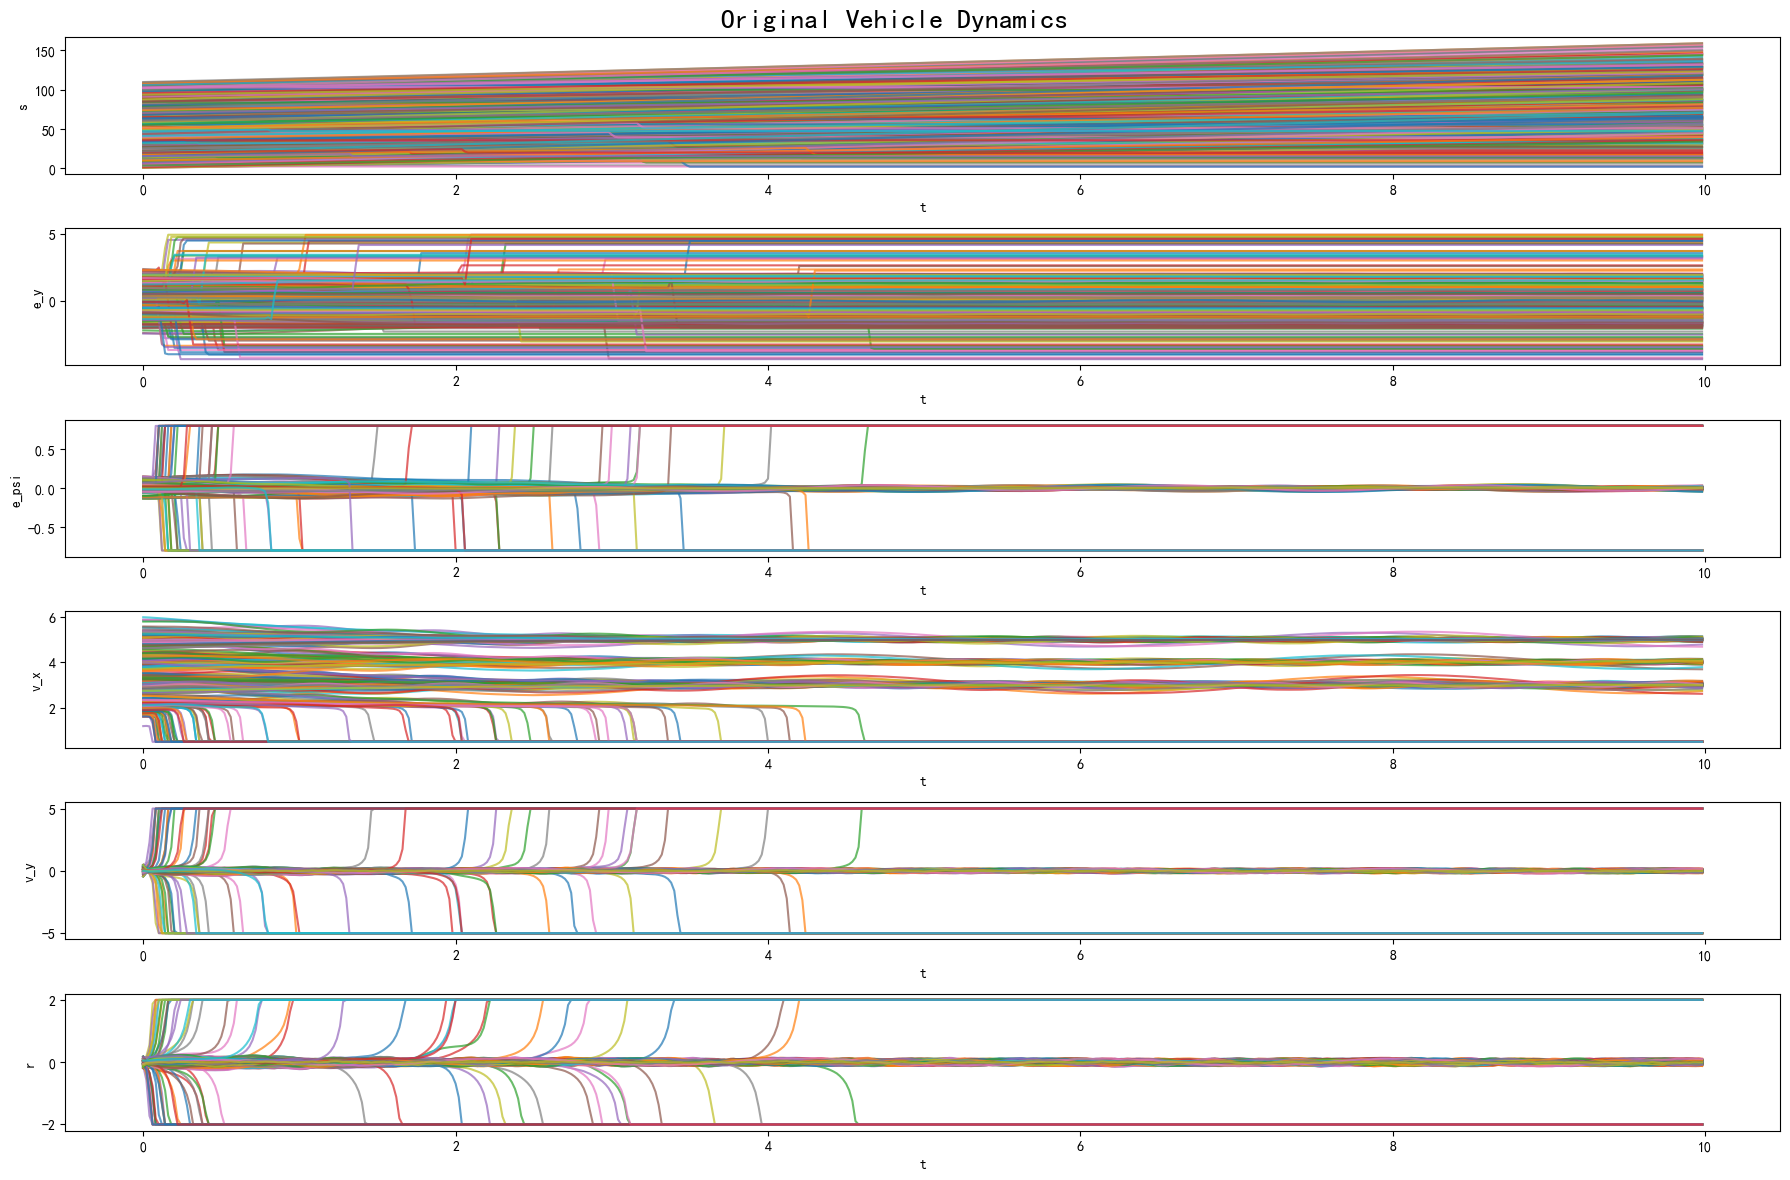

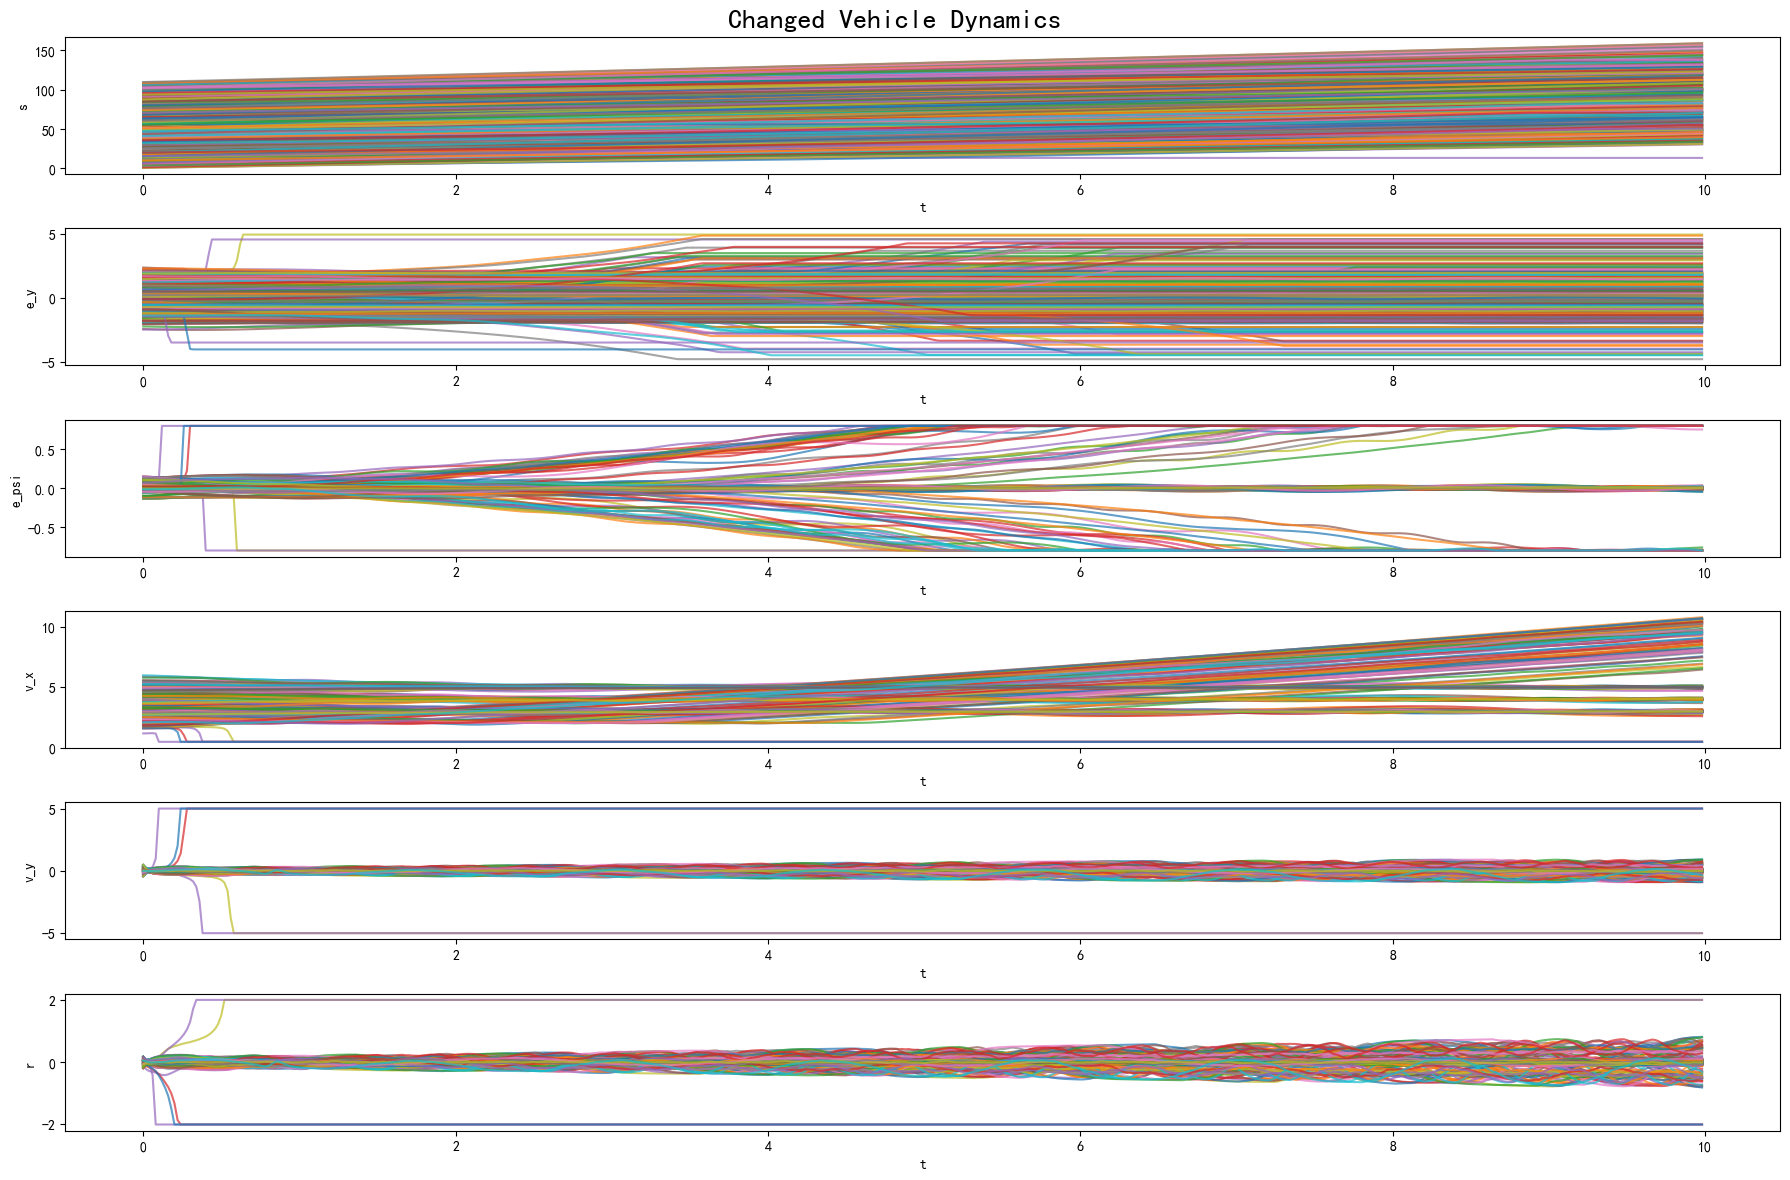

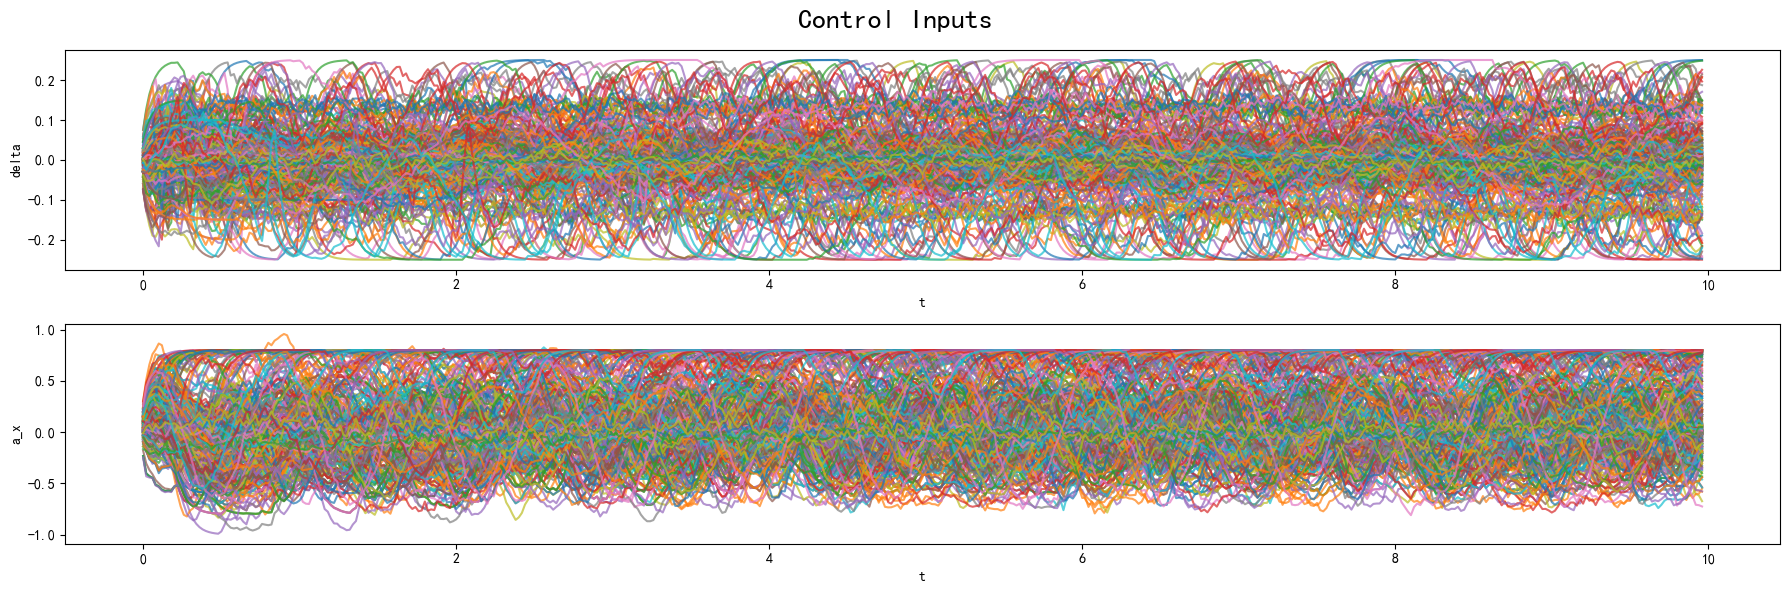

In [12]:


# =============================================================================
# 系统拟合
# =============================================================================
linear = True

# =============================================================================
# 数据生成 (针对 100m 双移线优化：丰富场景 + 物理不变性数据增强)
# =============================================================================
sys_pars_base = {}

# 6 states: x=[s, e_y, e_psi, v_x, v_y, r]
num_states = 6
num_inputs = 2
dt = 0.02

sys_pars_base["num_states"] = num_states
sys_pars_base["num_inputs"] = num_inputs
sys_pars_base["dt"] = dt

# nominal vehicle parameters
sys_pars_base["m"] = 1500.0
sys_pars_base["Iz"] = 2250.0
sys_pars_base["lf"] = 1.2
sys_pars_base["lr"] = 1.6
sys_pars_base["Cf"] = 80000.0
sys_pars_base["Cr"] = 80000.0
sys_pars_base["curvature_ref"] = 0.0
sys_pars_base["uncertainty"] = "NA"
sys_pars_base["amp"] = 0.0

sys_pars_base["road_modes"] = ['dlc']
sys_pars_base["road_mode_probs"] = [1.0]

sys_pars_base["u_modes"] = ['feedback_dominant', 'sinusoidal', 'mixed']
sys_pars_base["u_mode_probs"] = [0.40, 0.30, 0.30]  # 稍微调整激励比例

sys_pars_base["alpha_u"] = 0.70
sys_pars_base["s_margin"] = 15.0
sys_pars_base["seed"] = 42

# changed vehicle parameters
sys_pars_new_base = dict(sys_pars_base)
sys_pars_new_base["m"] = 1650.0
sys_pars_new_base["Iz"] = 2400.0
sys_pars_new_base["Cf"] = 70000.0
sys_pars_new_base["Cr"] = 70000.0

# sys_pars_new_base = dict(sys_pars_base)

sensor_noise = False
SNR_DB = 30
num_snaps = 500

configs = [
    {"vx_ref": 3.0, "delta_max": 0.10, "ax_max": 0.6, "freq": 1.0},
    {"vx_ref": 3.0, "delta_max": 0.20, "ax_max": 1.0, "freq": 0.5},  # 低频大转角，逼近紧急 DLC
    {"vx_ref": 4.0, "delta_max": 0.15, "ax_max": 0.8, "freq": 0.2},  # 中高速覆盖，拉大 e_y 侧移
    {"vx_ref": 5.0, "delta_max": 0.10, "ax_max": 0.8, "freq": 0.5},  # 高速覆盖
    {"vx_ref": 2.0, "delta_max": 0.25, "ax_max": 0.8, "freq": 0.5},  # 低速极大转角
]

num_traj_per_batch = 80
X_list, X_changed_list, U_list = [], [], []

print("正在生成覆盖双移线边界条件的多场景数据...")
for cfg in configs:
    sp = dict(sys_pars_base)
    sp.update(cfg)

    sp_new = dict(sys_pars_new_base)
    sp_new.update(cfg)

    X_b, X_changed_b, U_b = single_vehicle_data_gen_multi(
        num_traj_per_batch, num_snaps, sp, sp_new, sensor_noise, SNR_DB
    )
    X_list.append(X_b)
    X_changed_list.append(X_changed_b)
    U_list.append(U_b)

X = np.concatenate(X_list, axis=0)
X_changed = np.concatenate(X_changed_list, axis=0)
U = np.concatenate(U_list, axis=0)
num_traj = X.shape[0]  # Total 400

# 2. 【核心】数据增强 (Data Augmentation)
# 因为在直道上 (curvature_ref=0) 车辆的动态方程不受绝对纵向距离 s 和横向偏移 e_y 的影响
# 所以我们可以直接随机平移 s 和 e_y，扩大 Standardizer 的分布覆盖面，彻底解决饱和越界问题！
np.random.seed(42)
for i in range(num_traj):
    s_shift = np.random.uniform(0.0, 110.0)  # 覆盖 DLC 的 100m 长度
    ey_shift = np.random.uniform(-2.0, 2.0)  # 覆盖 DLC 的侧向偏差并留出充足泛化裕度

    X[i, :, 0] += s_shift
    X_changed[i, :, 0] += s_shift
    X[i, :, 1] += ey_shift
    X_changed[i, :, 1] += ey_shift

# 打乱数据以防止验证集切分时分布不均
indices = np.random.permutation(num_traj)
X = X[indices]
X_changed = X_changed[indices]
U = U[indices]

num_train = int(0.8 * num_traj)
num_val = num_traj - num_train

sys_pars = dict(sys_pars_base)
sys_pars.update({"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0})

sys_pars_new = dict(sys_pars_new_base)
sys_pars_new.update({"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0})

print("X shape:", X.shape)
print("X_changed shape:", X_changed.shape)
print("U shape:", U.shape)

os.makedirs("saved_data/single_vehicle", exist_ok=True)

np.savez_compressed(
    "saved_data/single_vehicle/offline_dataset.npz",
    X=X,
    X_changed=X_changed,
    U=U
)

with open("saved_data/single_vehicle/offline_dataset_pars.pkl", "wb") as f:
    pickle.dump({
        "sys_pars": sys_pars,
        "sys_pars_new": sys_pars_new,
        "num_traj": num_traj,
        "num_train": num_train,
        "num_val": num_val,
        "num_snaps": num_snaps,
        "sensor_noise": sensor_noise,
        "SNR_DB": SNR_DB
    }, f)

print("离线数据已保存。")

state_labels = ["s", "e_y", "e_psi", "v_x", "v_y", "r"]
input_labels = ["delta", "a_x"]
t_train = np.linspace(0, dt * (num_snaps - 1), num_snaps)

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Original Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X_changed[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Changed Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
for j in range(num_traj):
    for i in range(num_inputs):
        plt.subplot(num_inputs, 1, i + 1)
        plt.plot(t_train[:-1], U[j, :, i], alpha=0.7)
        plt.ylabel(input_labels[i])
        plt.xlabel("t")
plt.suptitle("Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()

Model save path: saved_models/single_vehicle/linear/Koop_vehicle_Dim20_dt_0.02.pth
进一步严格对齐检查...
原始形状 → xs_train: (320, 500, 6) | us_train: (320, 499, 2)
原始形状 → xs_val:   (80, 500, 6)   | us_val:   (80, 499, 2)
强制对齐后 → xs_train: (320, 499, 6) | us_train: (320, 499, 2)
强制对齐后 → xs_val:   (80, 499, 6)   | us_val:   (80, 499, 2)
✅ U_curr 与 X_curr 样本数匹配: 159680
✅ U_curr 与 X_curr 样本数匹配: 39920
Epoch [  10/300] | Train  total=1.5163e-03  pred=5.6538e-04  lifted=1.3387e-04| Val    total=1.5852e-03  pred=7.0991e-04  lifted=1.6441e-04
Epoch [  20/300] | Train  total=7.1336e-04  pred=5.2539e-04  lifted=3.2710e-04| Val    total=8.4175e-04  pred=6.6441e-04  lifted=3.4027e-04
Epoch [  30/300] | Train  total=5.3894e-04  pred=5.0746e-04  lifted=1.2303e-04| Val    total=6.7761e-04  pred=6.4757e-04  lifted=1.5262e-04
Epoch [  40/300] | Train  total=5.0782e-04  pred=4.9737e-04  lifted=1.3992e-04| Val    total=6.5008e-04  pred=6.3884e-04  lifted=1.6500e-04
Epoch [  50/300] | Train  total=5.0743e-04  pred=4.

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


Epoch [ 300/300] | Train  total=4.9969e-04  pred=4.9413e-04  lifted=1.1079e-04| Val    total=6.3656e-04  pred=6.2950e-04  lifted=1.4089e-04
✅ Koopman模型构造完成 | A: (27, 27) | B: (27, 2) | C: (6, 27)


Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


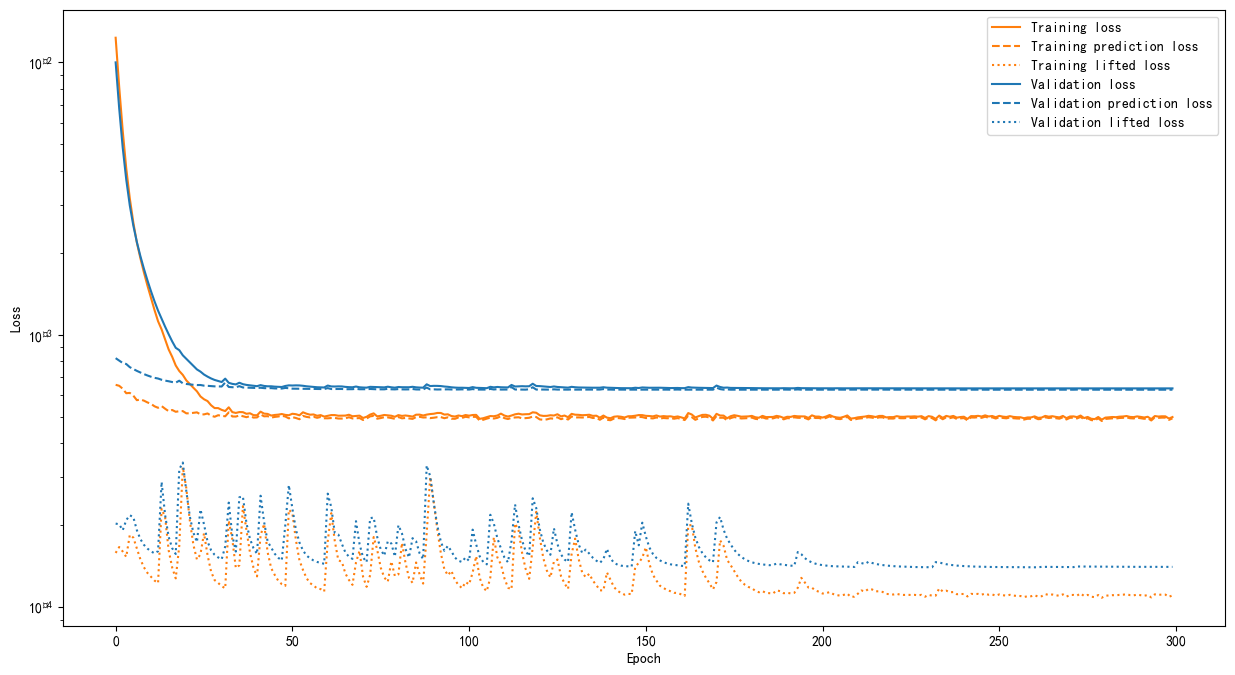

In [13]:

# =============================================================================
# Learning Koopman
# =============================================================================
xs_train, us_train = X[:num_train, :, :], U[:num_train, :, :]
xs_val, us_val = X[num_train:, :, :], U[num_train:, :, :]

net_params_lin = {}
net_params_lin["state_dim"] = num_states
net_params_lin["ctrl_dim"] = num_inputs
net_params_lin["encoder_hidden_width"] = 96
# 模型容量适度提升：场景增多变复杂了，给隐变量输出更多维度
net_params_lin["encoder_hidden_depth"] = 4
net_params_lin["encoder_output_dim"] = 20
net_params_lin["optimizer"] = "adam"
net_params_lin["activation_type"] = "tanh"
net_params_lin["lr"] = 5e-4
net_params_lin["epochs"] = 300
net_params_lin["batch_size"] = 4096

net_params_lin["eig_loss"] = True
net_params_lin["eig_loss_coeff"] = 0.2
net_params_lin["lifted_loss_penalty"] = 0.05

net_params_lin["l2_reg"] = 1e-4
net_params_lin["l1_reg"] = 1e-7
net_params_lin["first_obs_const"] = True
net_params_lin["override_C"] = True
net_params_lin["dt"] = dt
net_params_lin["weight_decay"] = 5e-5  # 轻微L2正则辅助

train = True
standardize = True

os.makedirs("saved_models/single_vehicle/linear", exist_ok=True)

file_koop_linear = (
        "saved_models/single_vehicle/linear/"
        + "Koop_vehicle_Dim"
        + str(net_params_lin["encoder_output_dim"])
        + "_dt_"
        + str(dt)
        + ".pth"
)

print("Model save path:", file_koop_linear)

standardizer_u_kdnn = fit_standardizer(
    us_train, preprocessing.StandardScaler(with_mean=True)
)
standardizer_x_kdnn = fit_standardizer(
    xs_train, preprocessing.StandardScaler(with_mean=True)
)

torch.backends.cudnn.benchmark = True
torch.backends.cuda.matmul.allow_tf32 = True
torch.set_float32_matmul_precision('high')
torch.cuda.empty_cache()

# RTX 50 系列额外推荐
torch.backends.cudnn.allow_tf32 = True
torch.backends.cuda.matmul.allow_tf32 = True

if train:
    if standardize:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            standardizer_x=standardizer_x_kdnn,
            standardizer_u=standardizer_u_kdnn,
            device=DEVICE
        )
    else:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            device=DEVICE
        )

    model_koop_dnn_lin = KoopDNN_linear(net)
    model_koop_dnn_lin.set_datasets(
        xs_train,
        u_train=us_train,
        x_val=xs_val,
        u_val=us_val
    )

    print("进一步严格对齐检查...")

    # ====================== 强制对齐 x 和 u 的轨迹长度 ======================
    print(f"原始形状 → xs_train: {xs_train.shape} | us_train: {us_train.shape}")
    print(f"原始形状 → xs_val:   {xs_val.shape}   | us_val:   {us_val.shape}")

    # 以 u 的长度为准（因为 u 通常比 x 少一步），统一裁剪 x
    min_t_train = min(xs_train.shape[1], us_train.shape[1])
    xs_train = xs_train[:, :min_t_train, :]
    us_train = us_train[:, :min_t_train, :]

    min_t_val = min(xs_val.shape[1], us_val.shape[1])
    xs_val = xs_val[:, :min_t_val, :]
    us_val = us_val[:, :min_t_val, :]

    print(f"强制对齐后 → xs_train: {xs_train.shape} | us_train: {us_train.shape}")
    print(f"强制对齐后 → xs_val:   {xs_val.shape}   | us_val:   {us_val.shape}")

    # 再次断言，确保 process 前完全一致
    assert xs_train.shape[1] == us_train.shape[1], f"对齐失败: x={xs_train.shape[1]} vs u={us_train.shape[1]}"
    assert xs_val.shape[1] == us_val.shape[1], f"val 对齐失败"

    # ====================== 先调用 process 生成数据（必须先做） ======================
    X_train, y_train = model_koop_dnn_lin.net.process(
        model_koop_dnn_lin.x_train, data_u=model_koop_dnn_lin.u_train
    )
    X_val, y_val = model_koop_dnn_lin.net.process(
        model_koop_dnn_lin.x_val, data_u=model_koop_dnn_lin.u_val, train_mode=False
    )

    # ====================== 针对 RTX 5080 的最终高效 GPU DataLoader ======================
    from torch.utils.data import TensorDataset, DataLoader

    # 关键：保持在 CPU，让 pin_memory 自动处理 pinned → GPU 异步拷贝
    X_train_t = torch.from_numpy(X_train).float()
    y_train_t = torch.from_numpy(y_train).float()
    X_val_t = torch.from_numpy(X_val).float()
    y_val_t = torch.from_numpy(y_val).float()

    train_dataset = TensorDataset(X_train_t, y_train_t)
    val_dataset = TensorDataset(X_val_t, y_val_t)

    train_loader = DataLoader(
        train_dataset,
        batch_size=net_params_lin["batch_size"],  # 6144
        shuffle=True,
        num_workers=0,  # 必须为 0（避免多进程与 GPU tensor 冲突）
        pin_memory=True,  # 必须打开
        drop_last=True,
        persistent_workers=False,
        prefetch_factor=None  # num_workers=0 时无需此参数
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=net_params_lin["batch_size"],
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )

    # ====================== 注入 loader ======================
    model_koop_dnn_lin.train_loader = train_loader
    model_koop_dnn_lin.val_loader = val_loader

    # 现在再调用 pipeline（这里面才会 construct_net）
    model_koop_dnn_lin.model_pipeline(net_params_lin, print_epoch=True)

    model_koop_dnn_lin.construct_koopman_model()

    torch.save(model_koop_dnn_lin, file_koop_linear)


else:
    model_koop_dnn_lin = torch.load(file_koop_linear, map_location=DEVICE)
    model_koop_dnn_lin.net.to(DEVICE)
    model_koop_dnn_lin.net.device = DEVICE

train_loss = [l[0] for l in model_koop_dnn_lin.train_loss_hist]
train_pred_loss = [l[1] for l in model_koop_dnn_lin.train_loss_hist]
train_lifted_loss = [l[2] for l in model_koop_dnn_lin.train_loss_hist]
val_loss = [l[0] for l in model_koop_dnn_lin.val_loss_hist]
val_pred_loss = [l[1] for l in model_koop_dnn_lin.val_loss_hist]
val_lifted_loss = [l[2] for l in model_koop_dnn_lin.val_loss_hist]
epochs = np.arange(0, net_params_lin["epochs"])

plt.figure(figsize=(15, 8))
plt.plot(epochs, train_loss, color="tab:orange", label="Training loss")
plt.plot(epochs, train_pred_loss, "--", color="tab:orange", label="Training prediction loss")
plt.plot(epochs, train_lifted_loss, ":", color="tab:orange", label="Training lifted loss")
plt.plot(epochs, val_loss, color="tab:blue", label="Validation loss")
plt.plot(epochs, val_pred_loss, "--", color="tab:blue", label="Validation prediction loss")
plt.plot(epochs, val_lifted_loss, ":", color="tab:blue", label="Validation lifted loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.show()

A, B, C shapes: (27, 27) (27, 2) (6, 27)
stable spectral radius = 0.99820864
A, B, C shapes: (27, 27) (27, 2) (6, 27)
spectral radius = 0.9982087
eigvals = [0.85343564+0.14605175j 0.85343564-0.14605175j 0.966242  +0.12129018j
 0.966242  -0.12129018j 0.9709491 +0.07935505j 0.9709491 -0.07935505j
 0.93877965+0.05740416j 0.93877965-0.05740416j 0.96631074+0.0453967j
 0.96631074-0.0453967j  0.9445502 +0.04532167j 0.9445502 -0.04532167j
 0.9974187 +0.00370029j 0.9974187 -0.00370029j 0.99820846+0.00067085j
 0.99820846-0.00067085j 0.99665403+0.j         0.9506504 +0.0358559j
 0.9506504 -0.0358559j  0.9257089 +0.j         0.9525672 +0.02598776j
 0.9525672 -0.02598776j 0.96262366+0.00352725j 0.96262366-0.00352725j
 0.9480196 +0.00859433j 0.9480196 -0.00859433j 0.940748  +0.j        ]


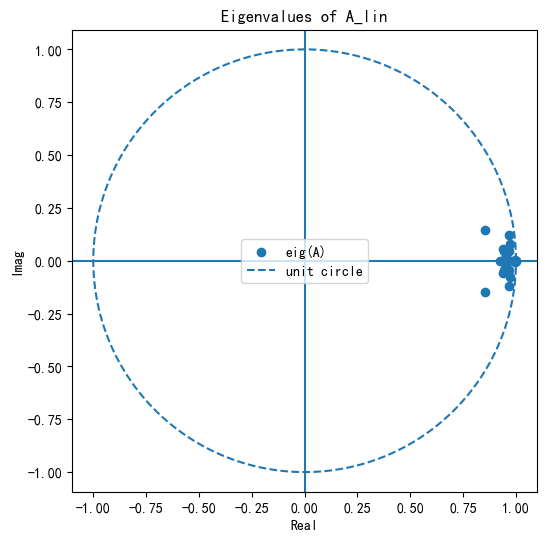

✅ U_curr 与 X_curr 样本数匹配: 99
✅ U_curr 与 X_curr 样本数匹配: 99
x_unchanged_scaled shape: (99, 6)
u_scaled shape: (99, 2)
x_changed_scaled shape: (99, 6)
x_changed_prime_scaled shape: (99, 0)


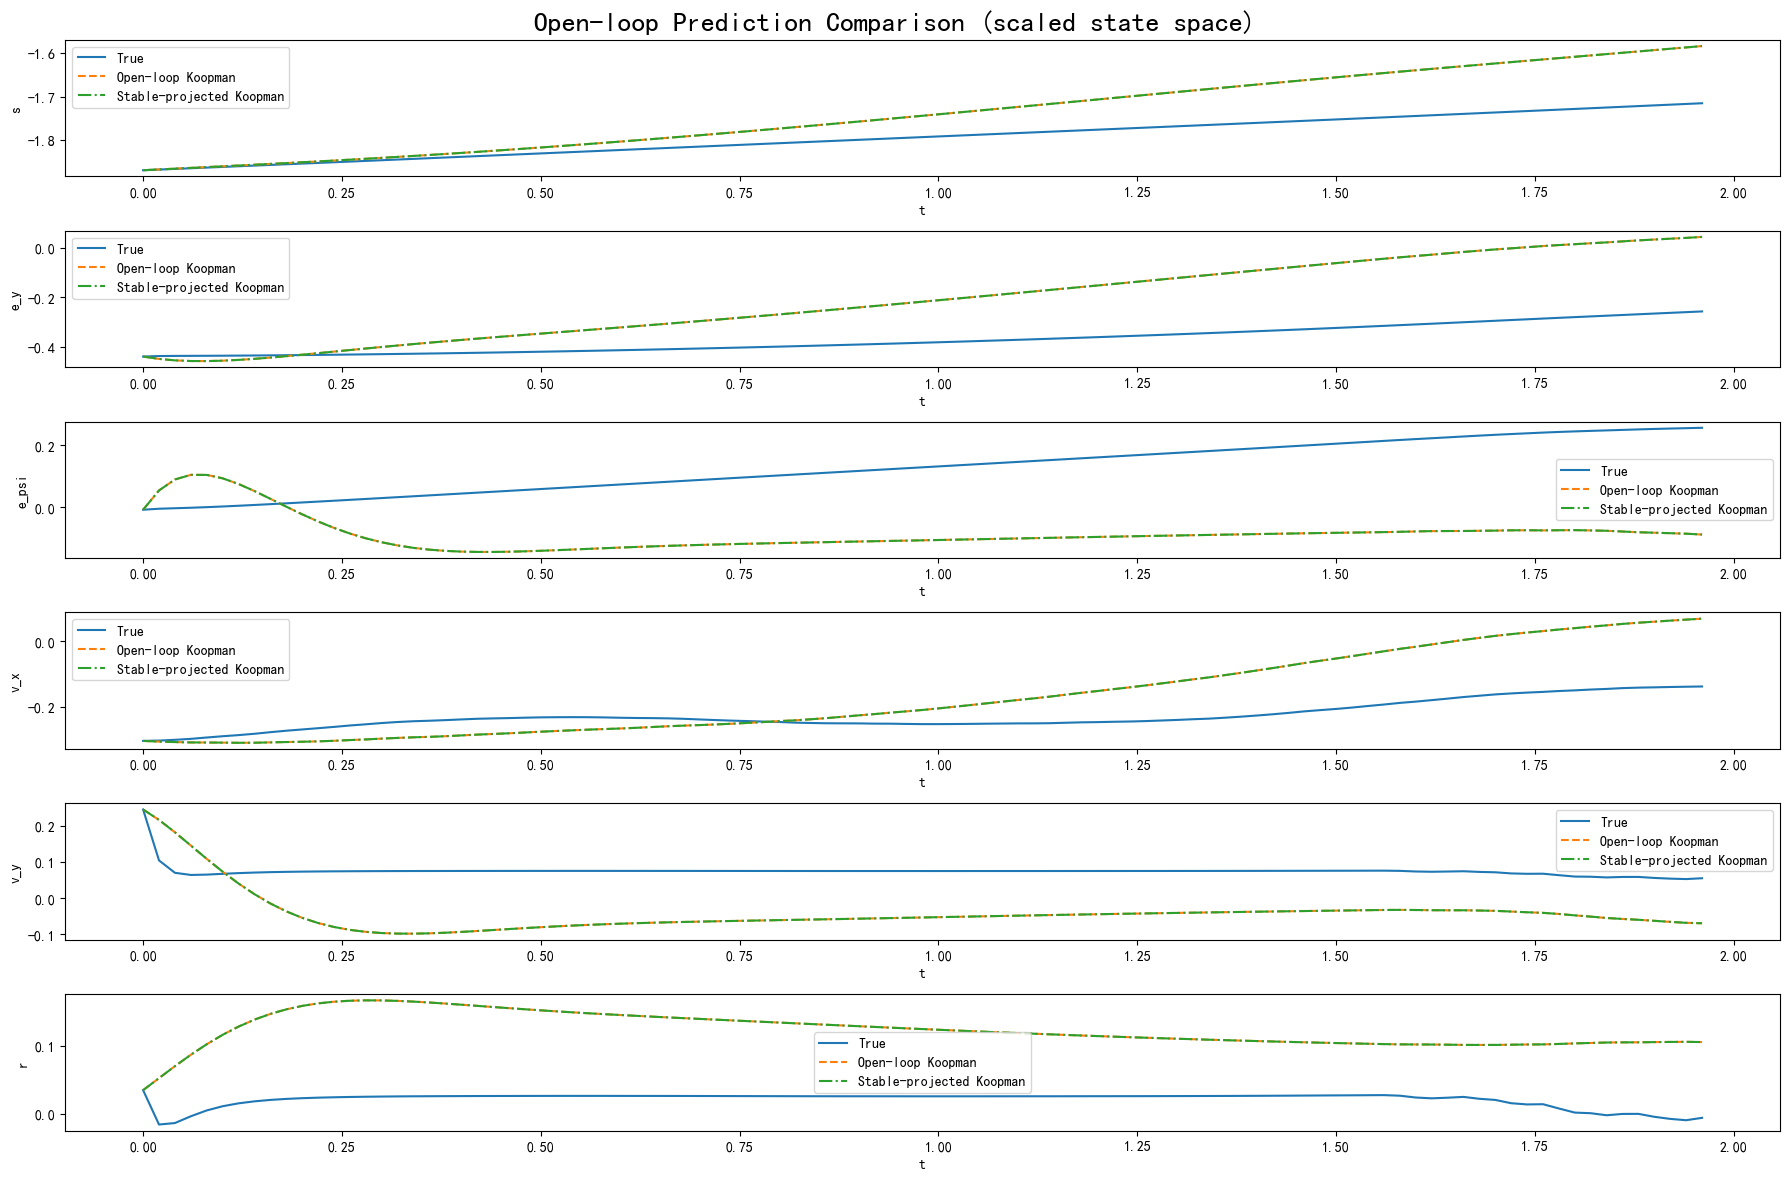

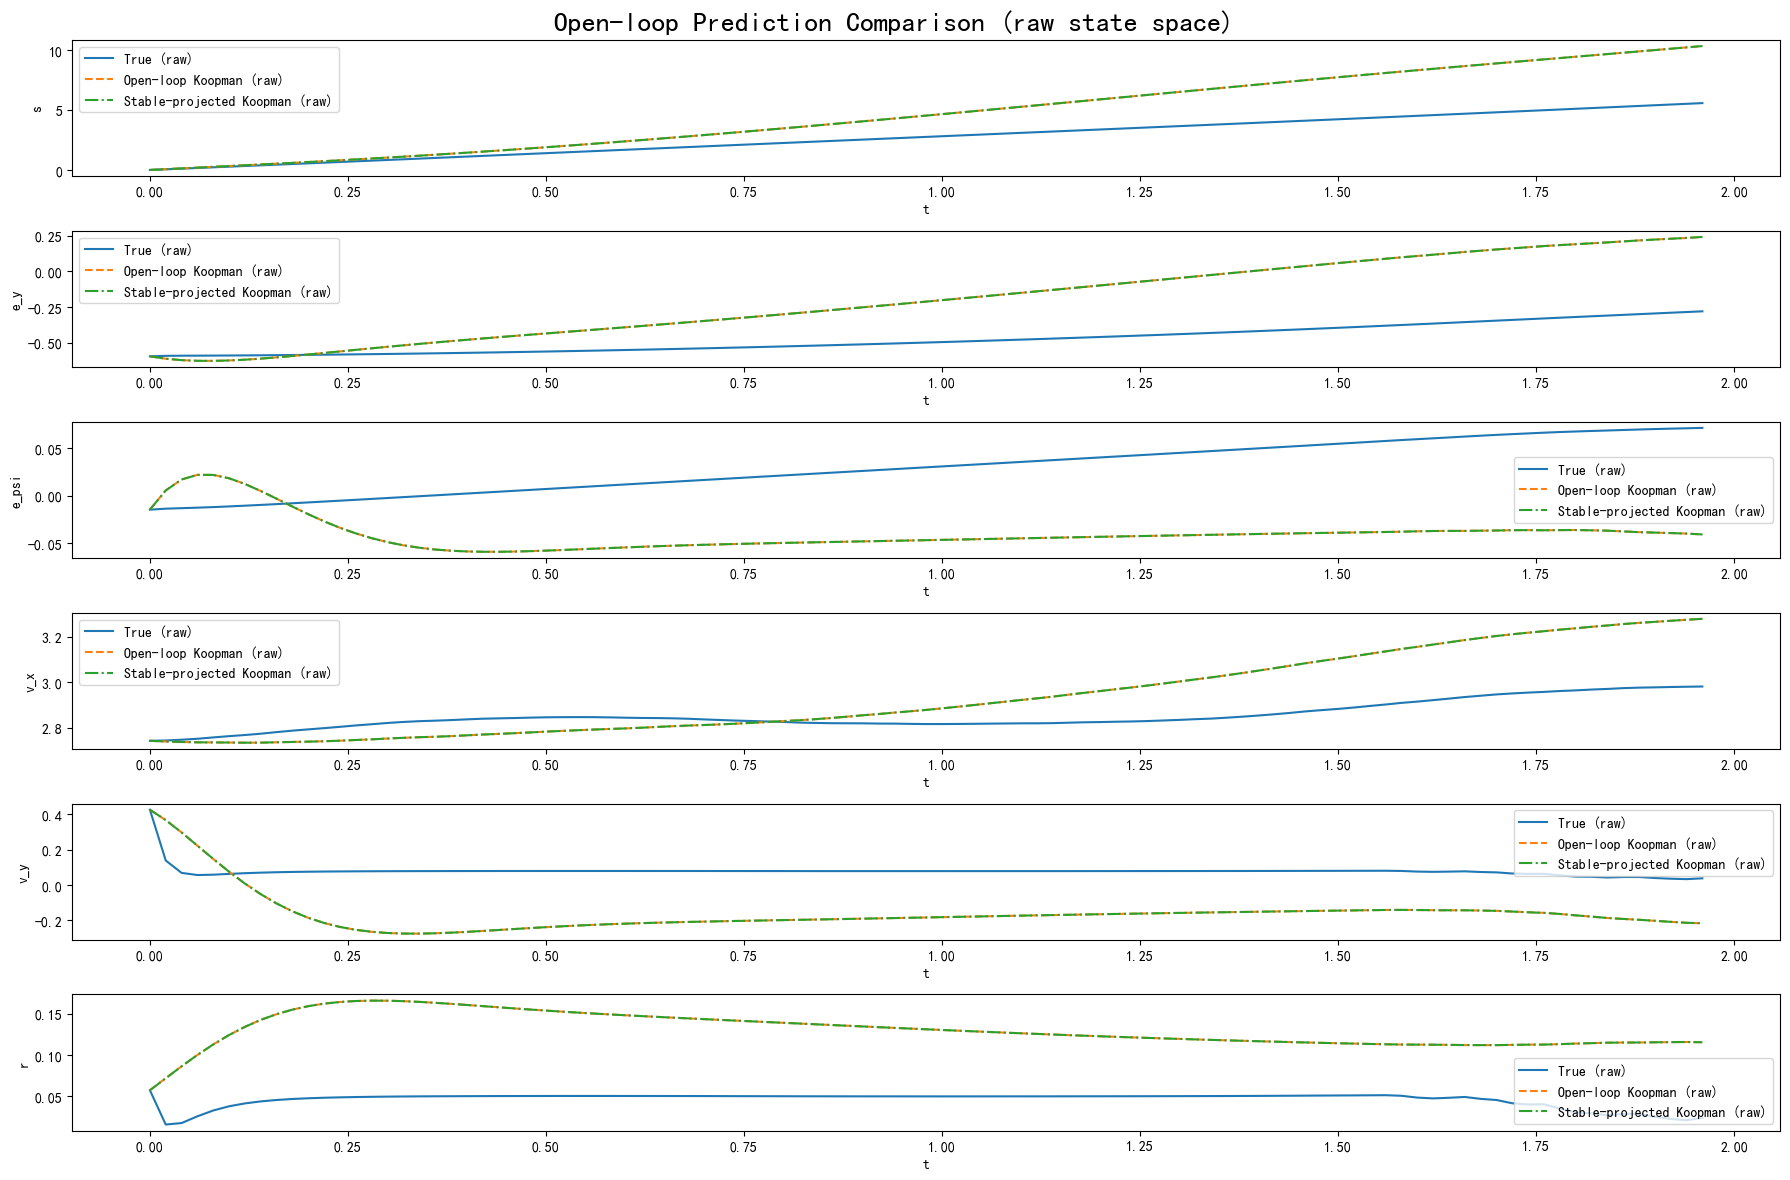

In [14]:

# =============================================================================
# Koopman Model Parameters (Open Loop Test)
# =============================================================================
num_snaps_test = 100
T_test = np.linspace(0, (num_snaps_test - 1) * dt, num_snaps_test)

num_traj_test = 1
first_obs_const = int(net_params_lin["first_obs_const"])
override_C = net_params_lin["override_C"]
if override_C:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + num_states + first_obs_const
else:
    n_obs_lin = int(net_params_lin["encoder_output_dim"]) + first_obs_const

x_unchanged_test, x_changed_test, u_test = single_vehicle_data_gen_multi(
    num_traj_test, num_snaps_test, sys_pars, sys_pars_new, sensor_noise, SNR_DB
)


# ====================== 正确提取 Koopman 矩阵 ======================
# ====================== 正确提取 Koopman 矩阵 ======================
if not hasattr(model_koop_dnn_lin, 'A_lin'):
    print("⚠️ 尚未调用 construct_koopman_model()，现在自动调用...")
    model_koop_dnn_lin.construct_koopman_model()

A_lin = model_koop_dnn_lin.A_lin
B_lin = model_koop_dnn_lin.B_lin
C_lin = model_koop_dnn_lin.C_np

print("A, B, C shapes:", A_lin.shape, B_lin.shape, C_lin.shape)

eigvals, eigvecs = np.linalg.eig(A_lin)
eigvals_proj = np.array([
    ev if np.abs(ev) <= 0.999 else ev / np.abs(ev) * 0.999
    for ev in eigvals
])
A_lin_stable = eigvecs @ np.diag(eigvals_proj) @ np.linalg.inv(eigvecs)
A_lin_stable = np.real(A_lin_stable)

eigvals_stable = np.linalg.eigvals(A_lin_stable)
print("stable spectral radius =", np.max(np.abs(eigvals_stable)))

print("A, B, C shapes:", A_lin.shape, B_lin.shape, C_lin.shape)

eigvals = np.linalg.eigvals(A_lin)
spectral_radius = np.max(np.abs(eigvals))

print("spectral radius =", spectral_radius)
print("eigvals =", eigvals)

plt.figure(figsize=(6, 6))
plt.scatter(np.real(eigvals), np.imag(eigvals), label="eig(A)")
theta = np.linspace(0, 2 * np.pi, 400)
plt.plot(np.cos(theta), np.sin(theta), "--", label="unit circle")
plt.axhline(0)
plt.axvline(0)
plt.xlabel("Real")
plt.ylabel("Imag")
plt.legend()
plt.title("Eigenvalues of A_lin")
plt.axis("equal")
plt.show()

X_unchanged_scaled, _ = model_koop_dnn_lin.net.process(x_unchanged_test, data_u=u_test)
X_changed_scaled, _ = model_koop_dnn_lin.net.process(x_changed_test, data_u=u_test)

x_unchanged_scaled = X_unchanged_scaled[:, :num_states]
u_scaled = X_unchanged_scaled[:, num_states:num_states + num_inputs]
x_unchanged_prime_scaled = X_unchanged_scaled[:, num_states + num_inputs:]

x_changed_scaled = X_changed_scaled[:, :num_states]
x_changed_prime_scaled = X_changed_scaled[:, num_states + num_inputs:]

print("x_unchanged_scaled shape:", x_unchanged_scaled.shape)
print("u_scaled shape:", u_scaled.shape)
print("x_changed_scaled shape:", x_changed_scaled.shape)
print("x_changed_prime_scaled shape:", x_changed_prime_scaled.shape)

num_pred = x_unchanged_scaled.shape[0]

z_lin = np.zeros((num_pred, n_obs_lin))
x_est_lin = np.zeros((num_pred, num_states))

z_lin[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)


x_est_lin[0, :] = np.matmul(z_lin[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin[k + 1, :] = np.matmul(z_lin[k, :], A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin[k + 1, :] = np.matmul(z_lin[k + 1, :], C_lin.T)

z_lin_stable = np.zeros((num_pred, n_obs_lin))
x_est_lin_stable = np.zeros((num_pred, num_states))

z_lin_stable[0, :] = lift_scaled(x_unchanged_scaled[0, :], model_koop_dnn_lin, net_params_lin)
x_est_lin_stable[0, :] = np.matmul(z_lin_stable[0, :], C_lin.T)

for k in range(num_pred - 1):
    z_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k, :], A_lin_stable.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_est_lin_stable[k + 1, :] = np.matmul(z_lin_stable[k + 1, :], C_lin.T)

T_plot = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_unchanged_scaled[:, i], label="True")
    plt.plot(T_plot, x_est_lin[:, i], "--", label="Open-loop Koopman")
    plt.plot(T_plot, x_est_lin_stable[:, i], "-.", label="Stable-projected Koopman")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

x_est_lin_raw = standardizer_x_kdnn.inverse_transform(x_est_lin)
x_est_lin_stable_raw = standardizer_x_kdnn.inverse_transform(x_est_lin_stable)
x_true_raw = x_unchanged_test[0, :-1, :]

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.xlabel("t")
    plt.ylabel(state_labels[i])
    plt.plot(T_plot, x_true_raw[:, i], label="True (raw)")
    plt.plot(T_plot, x_est_lin_raw[:, i], "--", label="Open-loop Koopman (raw)")
    plt.plot(T_plot, x_est_lin_stable_raw[:, i], "-.", label="Stable-projected Koopman (raw)")
    plt.legend()

plt.suptitle("Open-loop Prediction Comparison (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()

进行 one-step 预测 | 样本数: 99 | 状态维: 6


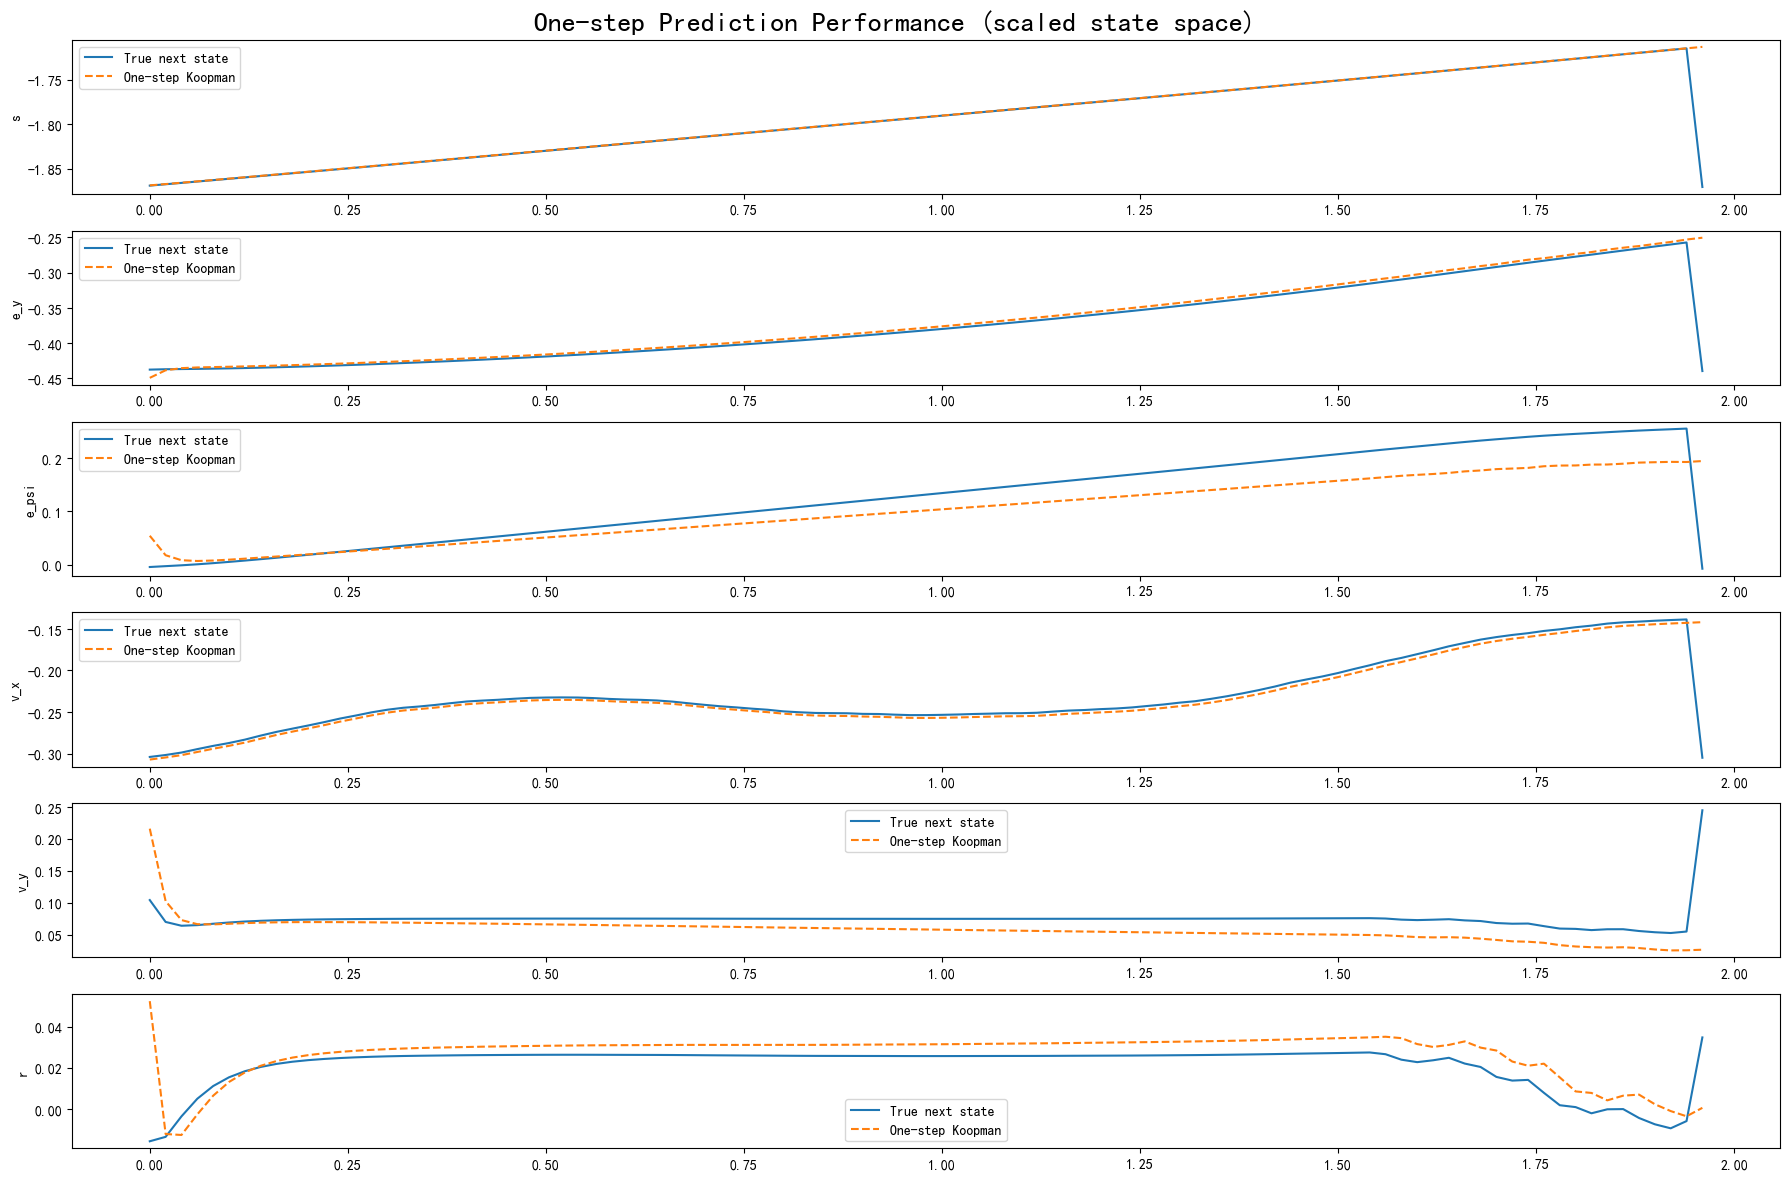

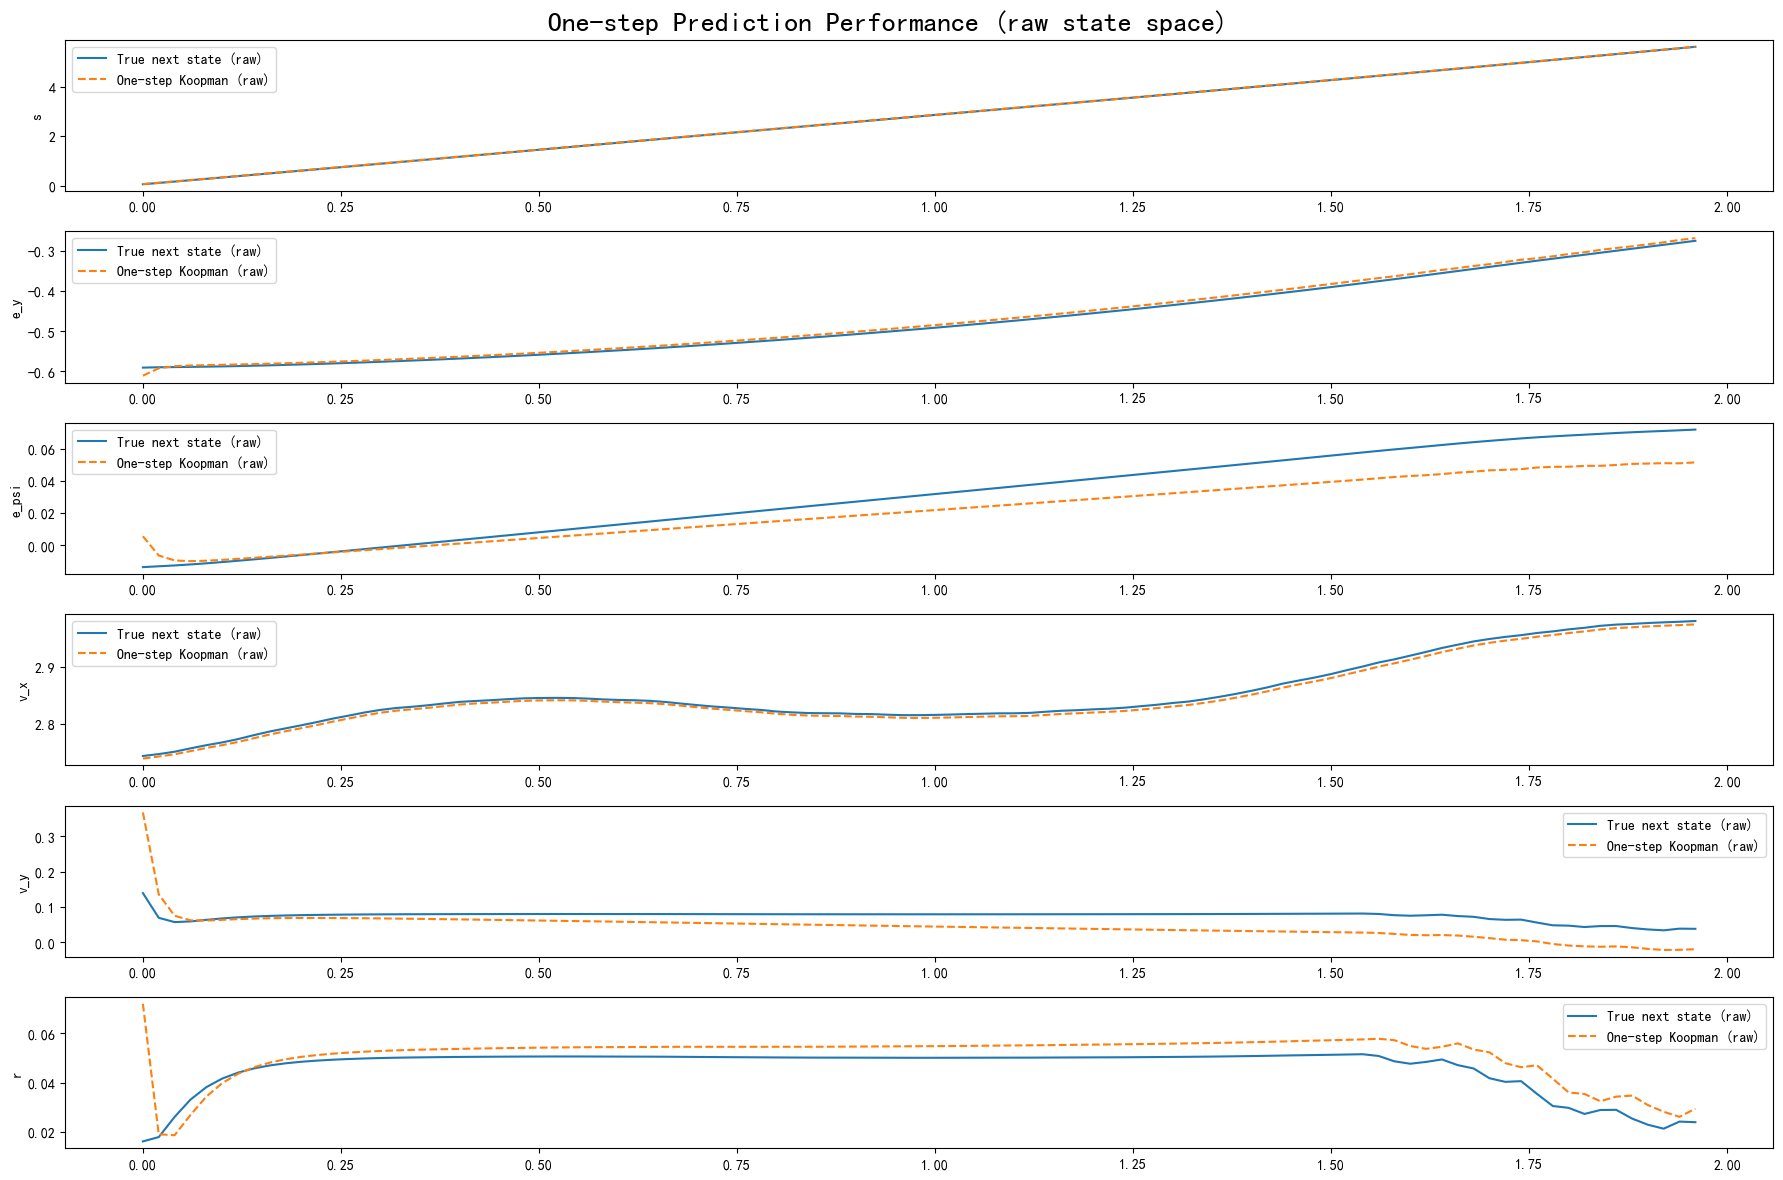

In [15]:

# ====================== One-step Prediction (修复空数组问题) ======================
# 正确计算有效样本数（process 已经切掉了最后一步）
num_pred = x_unchanged_scaled.shape[0]  # 应该等于 99

# 正确初始化（使用 num_pred 而不是像 x_unchanged_prime_scaled 这样可能为空的变量）
x_one_step_pred = np.zeros((num_pred, num_states))

print(f"进行 one-step 预测 | 样本数: {num_pred} | 状态维: {num_states}")

for k in range(num_pred):
    z_k = lift_scaled(x_unchanged_scaled[k, :], model_koop_dnn_lin, net_params_lin)
    z_k1 = np.matmul(z_k, A_lin.T) + np.matmul(u_scaled[k, :], B_lin.T)
    x_one_step_pred[k, :] = np.matmul(z_k1, C_lin.T)

T_plot_1 = np.arange(num_pred) * dt

# ====================== 绘图（scaled） ======================
plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)

    # 更符合逻辑的替代写法
    true_next = x_unchanged_prime_scaled[:num_pred, i] if x_unchanged_prime_scaled.shape[1] > 0 else np.roll(
        x_unchanged_scaled[:, i], -1)
    plt.plot(T_plot_1, true_next, label="True next state")

    plt.plot(T_plot_1, x_one_step_pred[:, i], "--", label="One-step Koopman")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (scaled state space)", fontsize=20)
plt.tight_layout()
plt.show()

# ====================== 绘图（raw） ======================
x_one_step_pred_raw = standardizer_x_kdnn.inverse_transform(x_one_step_pred)

# True next state（注意对齐）
x_true_next_raw = x_unchanged_test[0, 1:1 + num_pred, :]

T_plot_raw = np.arange(num_pred) * dt

plt.figure(figsize=(18, 12))
for i in range(num_states):
    plt.subplot(num_states, 1, i + 1)
    plt.plot(T_plot_raw, x_true_next_raw[:, i], label="True next state (raw)")
    plt.plot(T_plot_raw, x_one_step_pred_raw[:, i], "--", label="One-step Koopman (raw)")
    plt.ylabel(state_labels[i])
    plt.legend()
plt.suptitle("One-step Prediction Performance (raw state space)", fontsize=20)
plt.tight_layout()
plt.show()
#

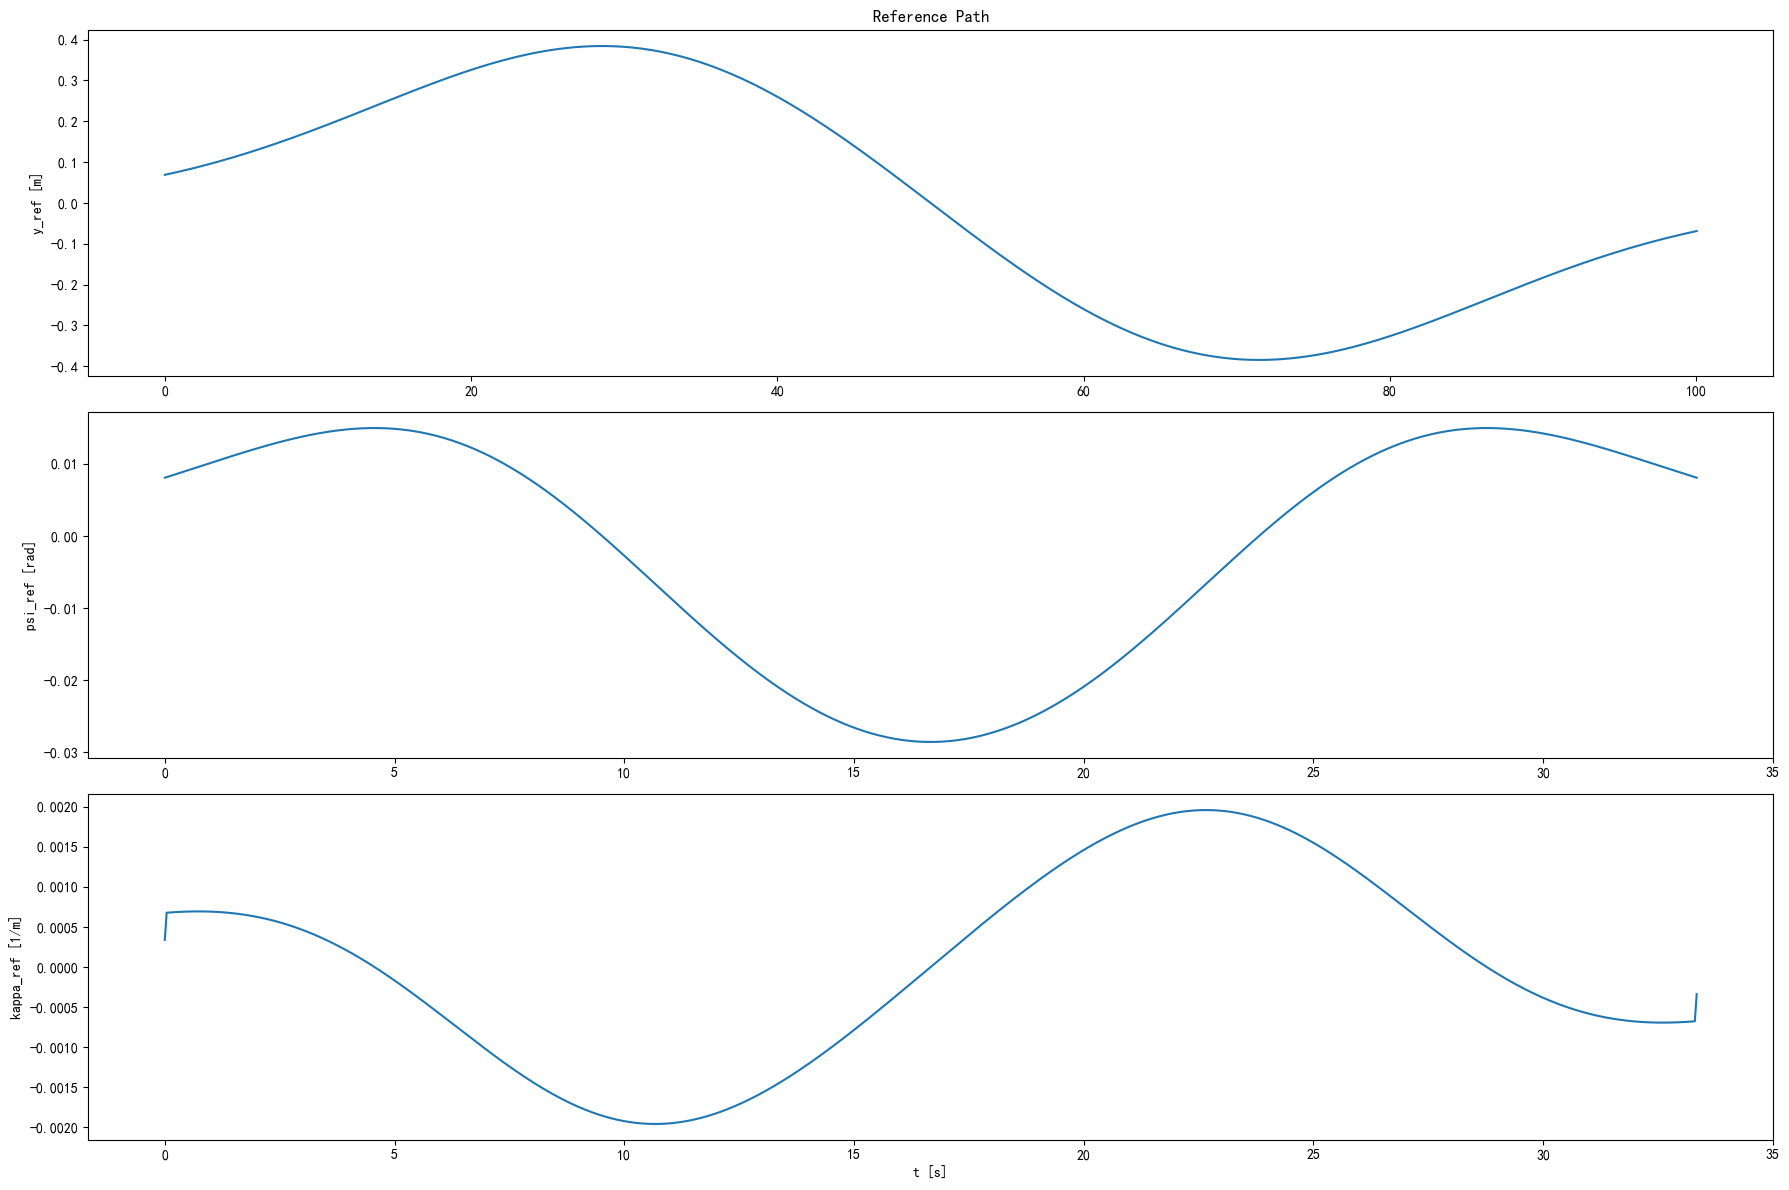

车 1 有效控制步数: 1667
车 2 有效控制步数: 1667
车 3 有效控制步数: 1667
车 4 有效控制步数: 1667

=== 四车协同仿真完成 ===
总仿真时间: 630.13 秒
平均每步时间: 0.3780 秒
各车 MPC 失败次数: [0, 0, 0, 0]
提前终止: False


In [16]:
#=============================================================================
# Testing - 100m Double Lane Change Baseline
# =============================================================================

# =========================
# 四车参数统一定义
# =========================
d_spacing = 5.0
num_vehicles = 4
vx_nom = 3.0

x0_vehicles = [
    np.array([0.0,  0.2, 0.0, vx_nom, 0.0, 0.0]),
    np.array([0.0, -0.2, 0.0, vx_nom, 0.0, 0.0]),
    np.array([-d_spacing,  0.2, 0.0, vx_nom, 0.0, 0.0]),
    np.array([-d_spacing, -0.2, 0.0, vx_nom, 0.0, 0.0])
]
# =========================
# Reference path generation
# =========================
path_length = 100.0

vx_nom = 3.0
T_traj = path_length / vx_nom
t_ref = np.arange(0, T_traj + dt, dt)
traj_length = t_ref.size
x_path = vx_nom * t_ref

A1 = 0.4
A2 = -0.4
x1 = 30.0
x2 = 70.0
sigma1 = 16.0
sigma2 = 16.0

y_ref_path = (
        A1 * np.exp(-0.5 * ((x_path - x1) / sigma1) ** 2)
        + A2 * np.exp(-0.5 * ((x_path - x2) / sigma2) ** 2)
)

s_ref_path, psi_ref_path, curvature_ref_path = build_test_frenet_path_from_xy(
    x_path, y_ref_path
)

x_ref_raw = np.zeros((num_states, traj_length))
x_ref_raw[0, :] = s_ref_path
x_ref_raw[1, :] = 0.0
x_ref_raw[2, :] = 0.0
x_ref_raw[3, :] = vx_nom
x_ref_raw[4, :] = 0.0
x_ref_raw[5, :] = vx_nom * curvature_ref_path

x_ref_scaled = standardizer_x_kdnn.transform(x_ref_raw.T).T

plt.figure(figsize=(18, 12))
plt.subplot(3, 1, 1)
plt.plot(x_path, y_ref_path)
plt.ylabel("y_ref [m]")
plt.title("Reference Path")

plt.subplot(3, 1, 2)
plt.plot(t_ref, psi_ref_path)
plt.ylabel("psi_ref [rad]")

plt.subplot(3, 1, 3)
plt.plot(t_ref, curvature_ref_path)
plt.ylabel("kappa_ref [1/m]")
plt.xlabel("t [s]")
plt.tight_layout()
plt.show()

# =========================
# Solver settings
# =========================
solver_settings = {}
solver_settings["gen_embedded_ctrl"] = False
solver_settings["warm_start"] = True
solver_settings["polish"] = True
solver_settings["polish_refine_iter"] = 5
solver_settings["scaling"] = True
solver_settings["adaptive_rho"] = True
solver_settings["check_termination"] = 25
solver_settings["max_iter"] = 30000
solver_settings["eps_abs"] = 5e-4
solver_settings["eps_rel"] = 5e-4
solver_settings["eps_prim_inf"] = 1e-3
solver_settings["eps_dual_inf"] = 1e-3

# 四车初始状态：纵向错开 d_spacing 米，横向队形可按需调整
d_spacing = 5.0  # 车间距 [m]，根据实际搬运刚体尺寸设定
num_vehicles = 4

# =========================
# 初始化四车参考轨迹列表（必须先定义！）
# =========================
x_ref_mpc_vehicles = []   # ←←← 这里是报错的根源，必须加上这一行



# =========================
# MPC horizon / ref preview
# =========================
N_lin_noadapt = 80
max_iter_lin = 5

for v in range(num_vehicles):
    x_ref_raw_v = x_ref_raw.copy()
    x_ref_raw_v[0, :] += x0_vehicles[v][0]      # s 纵向偏移
    x_ref_raw_v[1, :] = x0_vehicles[v][1]       # e_y 固定为队形位置（刚体约束）
    x_ref_raw_v[2, :] = 0.0                     # e_psi
    x_ref_raw_v[3, :] = vx_nom                  # v_x
    x_ref_raw_v[4:, :] = 0.0                    # v_y, r

    x_ref_scaled_v = standardizer_x_kdnn.transform(x_ref_raw_v.T).T

    x_ref_mpc_v = np.hstack((
        x_ref_scaled_v,
        np.tile(x_ref_scaled_v[:, -1].reshape(-1, 1), N_lin_noadapt + 2)
    ))
    x_ref_mpc_vehicles.append(x_ref_mpc_v)

# =========================
# Relaxed raw bounds -> scaled bounds
# =========================
xmin_raw = np.array([-10.0, -5.0, -1.2, 0.5, -4.0, -3.0])
xmax_raw = np.array([500.0, 5.0, 1.2, 8.0, 4.0, 3.0])

xmin_lin_noadapt = standardizer_x_kdnn.transform(xmin_raw.reshape(1, -1)).flatten()
xmax_lin_noadapt = standardizer_x_kdnn.transform(xmax_raw.reshape(1, -1)).flatten()

umax_lin_noadapt = np.array([0.08, 1.0])
umin_lin_noadapt = -umax_lin_noadapt

# =========================
# Closed-loop arrays in raw space
# =========================

xt_actual_vehicles = [np.zeros((traj_length, num_states)) for _ in range(num_vehicles)]
for v in range(num_vehicles):
    xt_actual_vehicles[v][0, :] = x0_vehicles[v]

u_vehicles = [np.zeros((traj_length - 1, num_inputs)) for _ in range(num_vehicles)]
z_vehicles = [np.zeros((traj_length, n_obs_lin)) for _ in range(num_vehicles)]

n_lift = A_lin.shape[0]

# =========================
# Initial guesses
# =========================


# ====================== 使用示例：准备基础权重 ======================
# 把你原来的固定权重改成“基础权重”
Q_base_lin = scipy.sparse.diags([
    0.0,  # s
    3500.0,  # e_y base
    1200.0,  # e_psi base
    8.0,  # v_x
    1.0,  # v_y
    1.0  # r
])

QN_base_lin = scipy.sparse.diags([
    0.0,
    5000.0,
    2000.0,
    12.0,
    1.0,
    1.0
])

R_mpc_lin_noadapt = scipy.sparse.diags([120.0, 12.0])  # R通常不自适应

# =========================
# Controller
# =========================
linear_model_no_adapt = linear_Dynamics(
    scipy.sparse.csc_matrix(A_lin_stable),
    scipy.sparse.csc_matrix(B_lin),
    C_lin
)


# =========================
controllers = []
z_inits = []

for v in range(num_vehicles):
    x_init_raw_v = np.tile(x0_vehicles[v], (N_lin_noadapt + 1, 1))
    u_init_v     = np.zeros((N_lin_noadapt, num_inputs))
    z_init_v     = np.zeros((N_lin_noadapt + 1, n_lift))

    for ii in range(N_lin_noadapt + 1):
        xii_scaled = scale_state(x_init_raw_v[ii, :], standardizer_x_kdnn)
        z_init_v[ii, :] = lift_scaled(xii_scaled, model_koop_dnn_lin, net_params_lin)

    z_inits.append(z_init_v)

    ctrl_v = NonlinearMPCController(
        linear_model_no_adapt,
        N_lin_noadapt, dt, umin_lin_noadapt, umax_lin_noadapt,
        xmin_lin_noadapt, xmax_lin_noadapt,
        Q_base_lin, R_mpc_lin_noadapt, QN_base_lin,
        solver_settings
    )

    ctrl_v.construct_controller(z_init_v, u_init_v, x_ref_mpc_vehicles[v][:, 0])

    controllers.append(ctrl_v)
# =========================
# 3. 定义自适应函数
# =========================

def adaptive_mpc_weights(error_ey, error_epsi, base_Q, base_QN, base_R,
                         ey_scale=0.8, epsi_scale=0.9,
                         max_mult=2.8, min_mult=0.85):
    ey_norm = min(abs(error_ey) / 1.8, 1.0)
    epsi_norm = min(abs(error_epsi) / 0.7, 1.0)

    mult_ey = 1.0 + (max_mult - 1.0) * (ey_norm ** 1.1)
    mult_epsi = 1.0 + (max_mult - 1.0) * (epsi_norm ** 1.1)

    mult_ey = np.clip(mult_ey * ey_scale, min_mult, max_mult)
    mult_epsi = np.clip(mult_epsi * epsi_scale, min_mult, max_mult)

    Q_diag = base_Q.diagonal().copy()
    QN_diag = base_QN.diagonal().copy()

    Q_diag[1] *= mult_ey
    Q_diag[2] *= mult_epsi
    QN_diag[1] *= mult_ey * 1.25
    QN_diag[2] *= mult_epsi * 1.25

    Q_adapt = scipy.sparse.diags(Q_diag, offsets=0, format='dia')
    QN_adapt = scipy.sparse.diags(QN_diag, offsets=0, format='dia')

    # R 轻微自适应（误差大时降低 R，让控制更主动）
    R_diag = base_R.diagonal().copy()
    mult_r = 1.0 - 0.25 * (max(mult_ey, mult_epsi) - 1.0)
    R_diag = R_diag * np.clip(mult_r, 0.75, 1.0)
    R_adapt = scipy.sparse.diags(R_diag, offsets=0, format='dia')

    return Q_adapt, QN_adapt, R_adapt


# =========================
# Closed-loop simulation
# =========================
delta_alpha = 0.6
ax_alpha = 0.50

sys_pars_ctrl = dict(sys_pars_new)
sys_pars_ctrl["vx_ref"] = vx_nom
sys_pars_ctrl["uncertainty"] = "NA"
sys_pars_ctrl["amp"] = 0.0
sys_pars_ctrl["freq"] = 1.0
sys_pars_ctrl["s_ref"] = s_ref_path
sys_pars_ctrl["curvature_ref"] = curvature_ref_path

begin_linear_noadapt = time.time()
time_excess = 0.0
fail_count = 0
nonfinite_count = 0
terminated_early = False


# 仿真参数保持不变
begin_time = time.time()
fail_counts = [0] * num_vehicles
terminated_early = False

for k in range(traj_length - 1):

    # ── 对每辆车并行求解（串行实现） ──────────────────────────────────
    for v in range(num_vehicles):
        xk_raw = xt_actual_vehicles[v][k, :].copy()

        if not is_finite_vector(xk_raw):
            print(f"[STOP] 车{v+1} 非有限状态 at step {k}")
            terminated_early = True
            break

        xk_raw = clip_closed_loop_state(xk_raw, s_upper=500.0)
        xt_actual_vehicles[v][k, :] = xk_raw

        # 自适应权重（与原单车逻辑完全相同，按车独立计算）
        current_ey   = xk_raw[1]
        current_epsi = xk_raw[2]
        if abs(current_ey) > 0.04 or abs(current_epsi) > 0.025:
            Q_adapt, QN_adapt, R_adapt = adaptive_mpc_weights(
                current_ey, current_epsi,
                Q_base_lin, QN_base_lin, R_mpc_lin_noadapt,
                ey_scale=0.8, epsi_scale=0.9, max_mult=2.8, min_mult=0.85
            )
        else:
            Q_adapt, QN_adapt, R_adapt = Q_base_lin, QN_base_lin, R_mpc_lin_noadapt

        controllers[v].Q  = Q_adapt
        controllers[v].QN = QN_adapt
        controllers[v].R  = R_adapt

        # scale & lift
        xk_scaled = scale_state(xk_raw, standardizer_x_kdnn)
        z_vehicles[v][k, :] = lift_scaled(xk_scaled, model_koop_dnn_lin, net_params_lin)

        # 参考窗口
        xref_win = x_ref_mpc_vehicles[v][:, k + 1:k + N_lin_noadapt + 2]

        # MPC 求解
        try:
            controllers[v].solve_to_convergence(
                xref_win, z_vehicles[v][k, :],
                controllers[v].z_init, controllers[v].u_init,
                max_iter=max_iter_lin, eps=1e-3
            )
            controllers[v].update_initial_guess_()
            delta_fb_mpc = float(controllers[v].cur_u[0, 0])
            ax_cmd       = float(controllers[v].cur_u[0, 1])
        except Exception as e:
            fail_counts[v] += 1
            print(f"[WARN] 车{v+1} MPC fallback at step {k}: {e}")
            if k > 0:
                delta_fb_mpc = float(u_vehicles[v][k - 1, 0])
                ax_cmd       = float(u_vehicles[v][k - 1, 1])
            else:
                delta_fb_mpc, ax_cmd = 0.0, 0.0

        # 前馈 + 裁剪
        ff_gain      = 0.8
        delta_ff     = ff_gain * (sys_pars["lf"] + sys_pars["lr"]) * curvature_ref_path[k]
        delta_cmd    = np.clip(delta_fb_mpc + delta_ff, umin_lin_noadapt[0], umax_lin_noadapt[0])
        ax_cmd       = np.clip(ax_cmd, umin_lin_noadapt[1], umax_lin_noadapt[1])

        # 输入平滑
        if k == 0:
            delta_applied = delta_cmd
            ax_applied    = ax_cmd
        else:
            delta_applied = delta_alpha * u_vehicles[v][k-1, 0] + (1 - delta_alpha) * delta_cmd
            ax_applied    = ax_alpha    * u_vehicles[v][k-1, 1] + (1 - ax_alpha)    * ax_cmd

        delta_applied = np.clip(delta_applied, umin_lin_noadapt[0], umax_lin_noadapt[0])
        ax_applied    = np.clip(ax_applied,    umin_lin_noadapt[1], umax_lin_noadapt[1])

        if k >= traj_length - 5 and k > 0:
            u_vehicles[v][k, :] = u_vehicles[v][k - 1, :]
        else:
            u_vehicles[v][k, 0] = delta_applied
            u_vehicles[v][k, 1] = ax_applied

        # 推进真实系统（每辆车用相同 sys_pars_ctrl，路径一致）
        x_next = safe_FK_step(
            xt_actual_vehicles[v][k, :], u_vehicles[v][k, :],
            sys_pars_ctrl, SNR_DB=SNR_DB, i=k,
            fallback_state=xt_actual_vehicles[v][k, :].copy(), verbose=True
        )
        xt_actual_vehicles[v][k + 1, :] = x_next

    if terminated_early:
        break

# =========================
# 仿真结束后的统计与打印
# =========================
end_linear_noadapt = time.time()

# 计算每辆车的有效控制步数（避免除零）
effective_steps_per_vehicle = []
for v in range(num_vehicles):
    u_v = u_vehicles[v]
    effective = max(1, np.sum(np.any(np.abs(u_v) > 0, axis=1)))
    effective_steps_per_vehicle.append(effective)
    print(f"车 {v+1} 有效控制步数: {effective}")

# 整体平均 MPC 求解时间
total_time = end_linear_noadapt - begin_time
avg_time_per_step = total_time / max(1, traj_length - 1)

print("\n=== 四车协同仿真完成 ===")
print(f"总仿真时间: {total_time:.2f} 秒")
print(f"平均每步时间: {avg_time_per_step:.4f} 秒")
print(f"各车 MPC 失败次数: {fail_counts}")
print(f"提前终止: {terminated_early}")



四车协同仿真完成，总耗时: 630.15 秒
车 1 有效控制步数: 1667 | MPC失败次数: 0
车 2 有效控制步数: 1667 | MPC失败次数: 0
车 3 有效控制步数: 1667 | MPC失败次数: 0
车 4 有效控制步数: 1667 | MPC失败次数: 0
提前终止: False


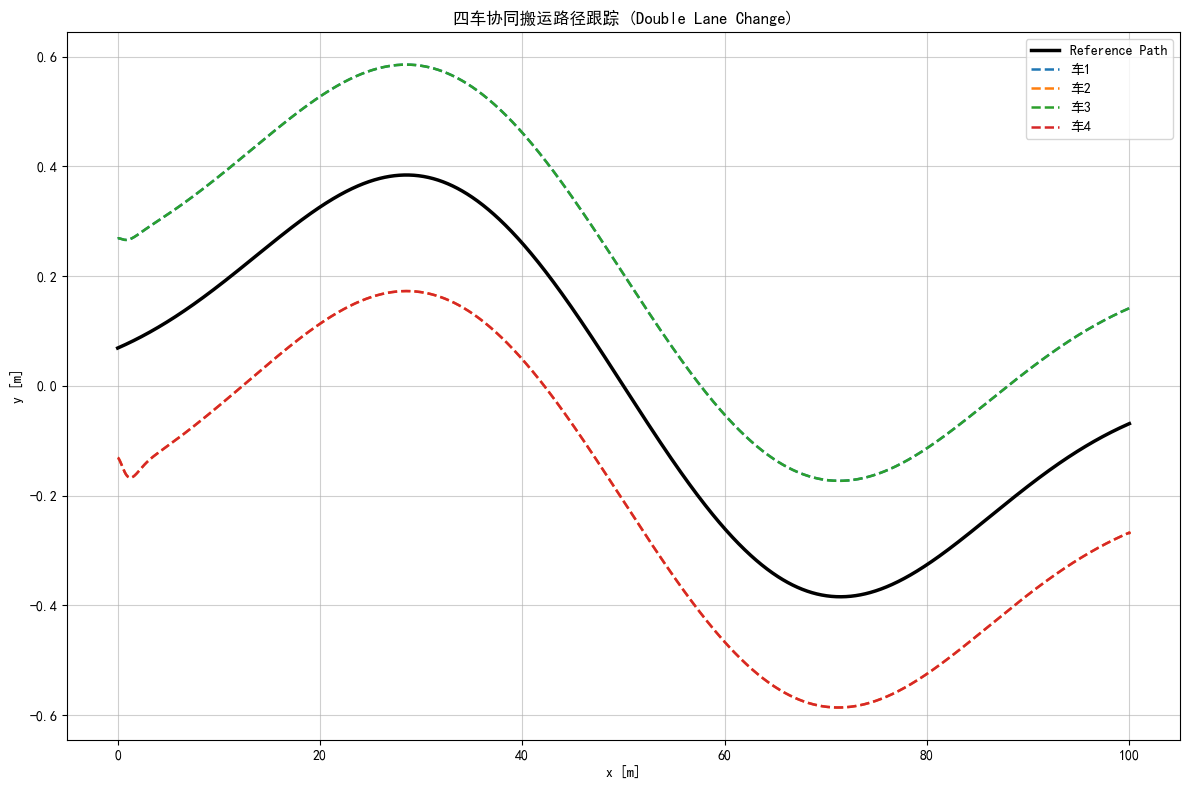

In [17]:
# =========================
# 仿真结束统计
# =========================
end_time = time.time()
print(f"\n四车协同仿真完成，总耗时: {(end_time - begin_time):.2f} 秒")

for v in range(num_vehicles):
    effective = max(1, np.sum(np.any(np.abs(u_vehicles[v]) > 0, axis=1)))
    print(f"车 {v+1} 有效控制步数: {effective} | MPC失败次数: {fail_counts[v]}")

print(f"提前终止: {terminated_early}")

# =========================
# Plotting
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 8))
plt.plot(x_path, y_ref_path, label="Reference Path", linewidth=2.5, color='black')

colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
for v in range(num_vehicles):
    valid_len_v = traj_length
    for idx in range(traj_length):
        if not is_finite_vector(xt_actual_vehicles[v][idx, :]):
            valid_len_v = idx
            break

    s_v = xt_actual_vehicles[v][:valid_len_v, 0]
    ey_v = xt_actual_vehicles[v][:valid_len_v, 1]
    x_v, y_v = frenet_to_global(s_v, ey_v, s_ref_path, x_path, y_ref_path, psi_ref_path)

    plt.plot(x_v, y_v, "--", color=colors[v], linewidth=1.8, label=f"车{v+1}")

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("四车协同搬运路径跟踪 (Double Lane Change)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

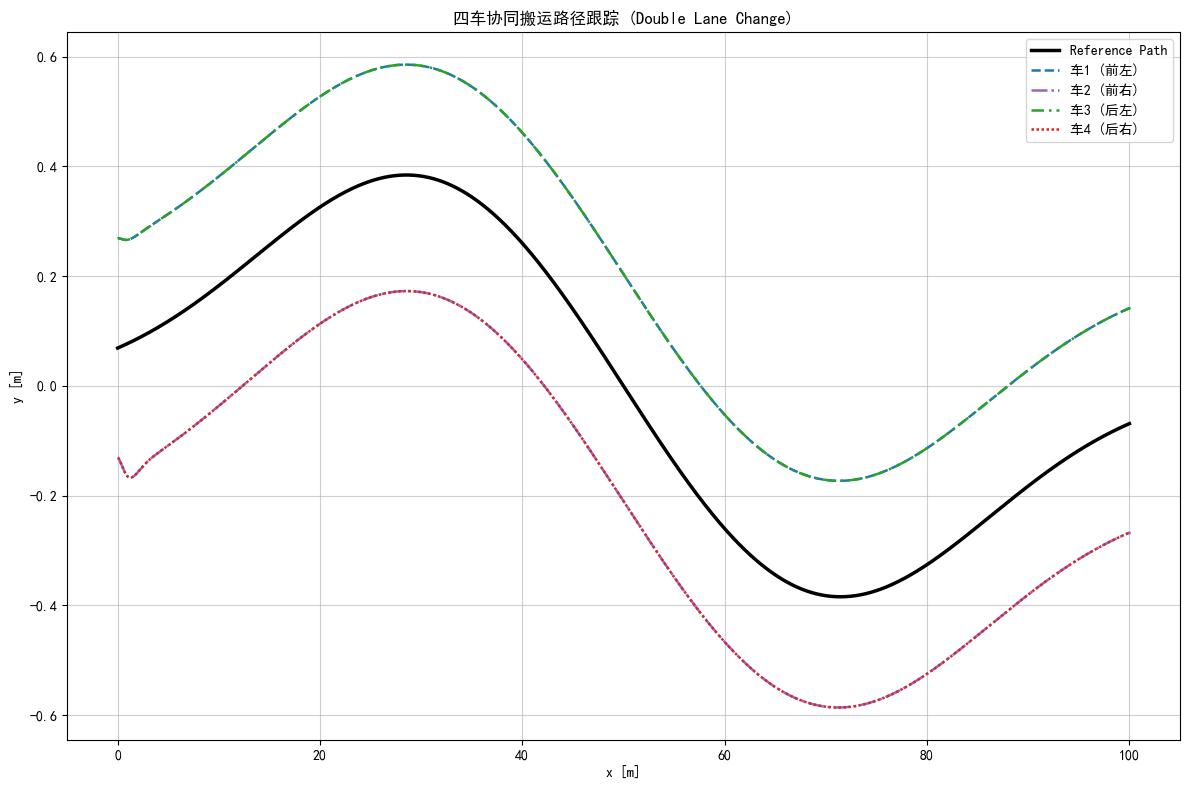


=== 各车轨迹诊断 ===
车1 → 有效步数: 1668/1668 | 最终s位置: 103.34 m
车2 → 有效步数: 1668/1668 | 最终s位置: 125.43 m
车3 → 有效步数: 1668/1668 | 最终s位置: 103.34 m
车4 → 有效步数: 1668/1668 | 最终s位置: 125.43 m


In [21]:
# =========================
# Plotting - 四车协同路径跟踪（四车不同线条版）
# =========================
# 解决中文显示问题
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

plt.figure(figsize=(12, 8))
plt.plot(x_path, y_ref_path, label="Reference Path", linewidth=2.5, color='black')

# 四车不同线条样式（颜色 + 线型组合，更易区分）
styles = [
    {'color': 'tab:blue',   'linestyle': '--',  'marker': 'o','linewidth': 1.8, 'label': '车1 (前左)'},
    {'color': 'tab:purple', 'linestyle': '-.',  'marker': 's','linewidth': 1.8, 'label': '车2 (前右)'},
    {'color': 'tab:green',  'linestyle': (0, (5,2,1,2)),   'marker': '^','linewidth': 1.8, 'label': '车3 (后左)'},
    {'color': 'tab:red',    'linestyle': (0, (1,1)),   'marker': 'D','linewidth': 1.8, 'label': '车4 (后右)'}
]

for v in range(num_vehicles):
    # 更鲁棒的有效长度判断：允许少量非有限值，只取最后一个有效索引
    valid_mask = np.array([is_finite_vector(xt_actual_vehicles[v][idx, :])
                          for idx in range(traj_length)])

    if not np.any(valid_mask):
        print(f"⚠️ 车{v+1} 全部状态无效，无轨迹可画")
        continue

    valid_indices = np.where(valid_mask)[0]
    valid_len_v = valid_indices[-1] + 1

    # 提取有效数据
    s_v = xt_actual_vehicles[v][:valid_len_v, 0]
    ey_v = xt_actual_vehicles[v][:valid_len_v, 1]

    # 保护：裁剪s范围，避免插值越界
    s_min = s_ref_path.min() - 10.0
    s_max = s_ref_path.max() + 10.0
    s_v = np.clip(s_v, s_min, s_max)

    # Frenet转全局坐标
    x_v, y_v = frenet_to_global(
        s_v, ey_v,
        s_ref_path, x_path, y_ref_path, psi_ref_path
    )

    # 使用不同线条样式绘制
    plt.plot(x_v, y_v,
             color=styles[v]['color'],
             linestyle=styles[v]['linestyle'],
             linewidth=styles[v]['linewidth'],
             label=styles[v]['label'])

plt.xlabel("x [m]")
plt.ylabel("y [m]")
plt.title("四车协同搬运路径跟踪 (Double Lane Change)")
plt.legend(loc='upper right')
plt.grid(True, alpha=0.6)
plt.tight_layout()
plt.show()

# ====================== 额外诊断信息 ======================
print("\n=== 各车轨迹诊断 ===")
for v in range(num_vehicles):
    valid_count = sum(is_finite_vector(xt_actual_vehicles[v][idx, :])
                     for idx in range(traj_length))
    last_valid_s = xt_actual_vehicles[v][valid_count-1, 0] if valid_count > 0 else "N/A"
    print(f"车{v+1} → 有效步数: {valid_count}/{traj_length} | 最终s位置: {last_valid_s:.2f} m")

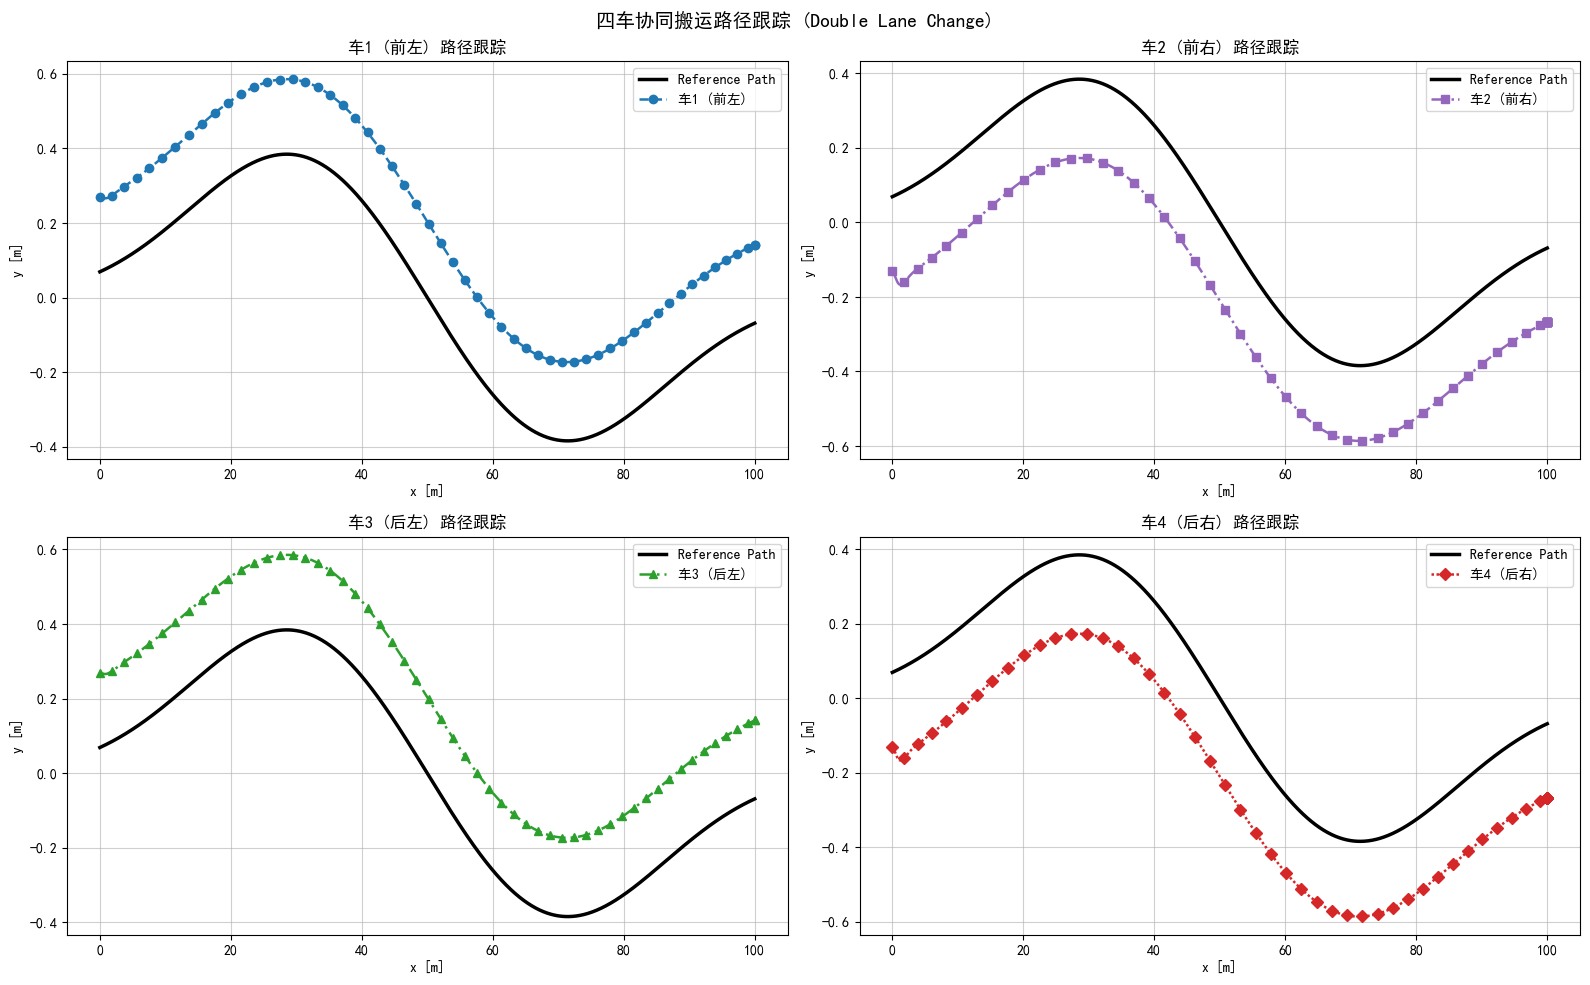


=== 各车轨迹诊断 ===
车1 → 有效步数: 1668/1668 | 最终s位置: 103.34 m
车2 → 有效步数: 1668/1668 | 最终s位置: 125.43 m
车3 → 有效步数: 1668/1668 | 最终s位置: 103.34 m
车4 → 有效步数: 1668/1668 | 最终s位置: 125.43 m


In [22]:
# =========================
# Plotting - 四车协同路径跟踪（四子图版）
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

styles = [
    {'color': 'tab:blue',   'linestyle': '--',           'marker': 'o', 'markevery': 30, 'linewidth': 1.8, 'label': '车1 (前左)'},
    {'color': 'tab:purple', 'linestyle': '-.',           'marker': 's', 'markevery': 30, 'linewidth': 1.8, 'label': '车2 (前右)'},
    {'color': 'tab:green',  'linestyle': (0, (5,2,1,2)),'marker': '^', 'markevery': 30, 'linewidth': 1.8, 'label': '车3 (后左)'},
    {'color': 'tab:red',    'linestyle': (0, (1,1)),     'marker': 'D', 'markevery': 30, 'linewidth': 1.8, 'label': '车4 (后右)'}
]

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()   # 变成 [ax0, ax1, ax2, ax3]，方便用索引访问

for v in range(num_vehicles):
    ax = axes[v]

    # 画参考路径（每个子图都画）
    ax.plot(x_path, y_ref_path, label="Reference Path", linewidth=2.5,
            color='black', linestyle='-')

    # 有效长度判断
    valid_mask = np.array([is_finite_vector(xt_actual_vehicles[v][idx, :])
                           for idx in range(traj_length)])

    if not np.any(valid_mask):
        ax.set_title(f"车{v+1} - 全部状态无效")
        continue

    valid_indices = np.where(valid_mask)[0]
    valid_len_v = valid_indices[-1] + 1

    s_v  = xt_actual_vehicles[v][:valid_len_v, 0]
    ey_v = xt_actual_vehicles[v][:valid_len_v, 1]

    # 裁剪 s 范围
    s_min = s_ref_path.min() - 10.0
    s_max = s_ref_path.max() + 10.0
    s_v = np.clip(s_v, s_min, s_max)

    # Frenet → 全局坐标
    x_v, y_v = frenet_to_global(
        s_v, ey_v,
        s_ref_path, x_path, y_ref_path, psi_ref_path
    )

    # 画该车轨迹
    ax.plot(x_v, y_v,
            color=styles[v]['color'],
            linestyle=styles[v]['linestyle'],
            marker=styles[v]['marker'],
            markevery=styles[v]['markevery'],
            linewidth=styles[v]['linewidth'],
            label=styles[v]['label'])

    ax.set_title(f"{styles[v]['label']} 路径跟踪")
    ax.set_xlabel("x [m]")
    ax.set_ylabel("y [m]")
    ax.legend(loc='upper right')
    ax.grid(True, alpha=0.6)

fig.suptitle("四车协同搬运路径跟踪 (Double Lane Change)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ====================== 诊断信息 ======================
print("\n=== 各车轨迹诊断 ===")
for v in range(num_vehicles):
    valid_count = sum(is_finite_vector(xt_actual_vehicles[v][idx, :])
                     for idx in range(traj_length))
    last_valid_s = xt_actual_vehicles[v][valid_count - 1, 0] if valid_count > 0 else "N/A"
    print(f"车{v+1} → 有效步数: {valid_count}/{traj_length} | 最终s位置: {last_valid_s:.2f} m")

C:\Users\lj\AppData\Local\Temp\ipykernel_45120\3603268251.py:71: UserWarning: Glyph 8339 (\N{LATIN SUBSCRIPT SMALL LETTER X}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_45120\3603268251.py:71: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_45120\3603268251.py:72: UserWarning: Glyph 8339 (\N{LATIN SUBSCRIPT SMALL LETTER X}) missing from font(s) SimHei.
  plt.savefig('inputs_separated.png', dpi=150, bbox_inches='tight')
C:\Users\lj\AppData\Local\Temp\ipykernel_45120\3603268251.py:72: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig('inputs_separated.png', dpi=150, bbox_inches='tight')
E:\anaconda\envs\pytorch_new\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8339 (\N{LATIN SUBSCRIPT SMALL LETTER X}) missing from font(s) SimHei.
  fig.canvas.print_figure(bytes_io, **kw)
E:\anaconda\envs\pytorc

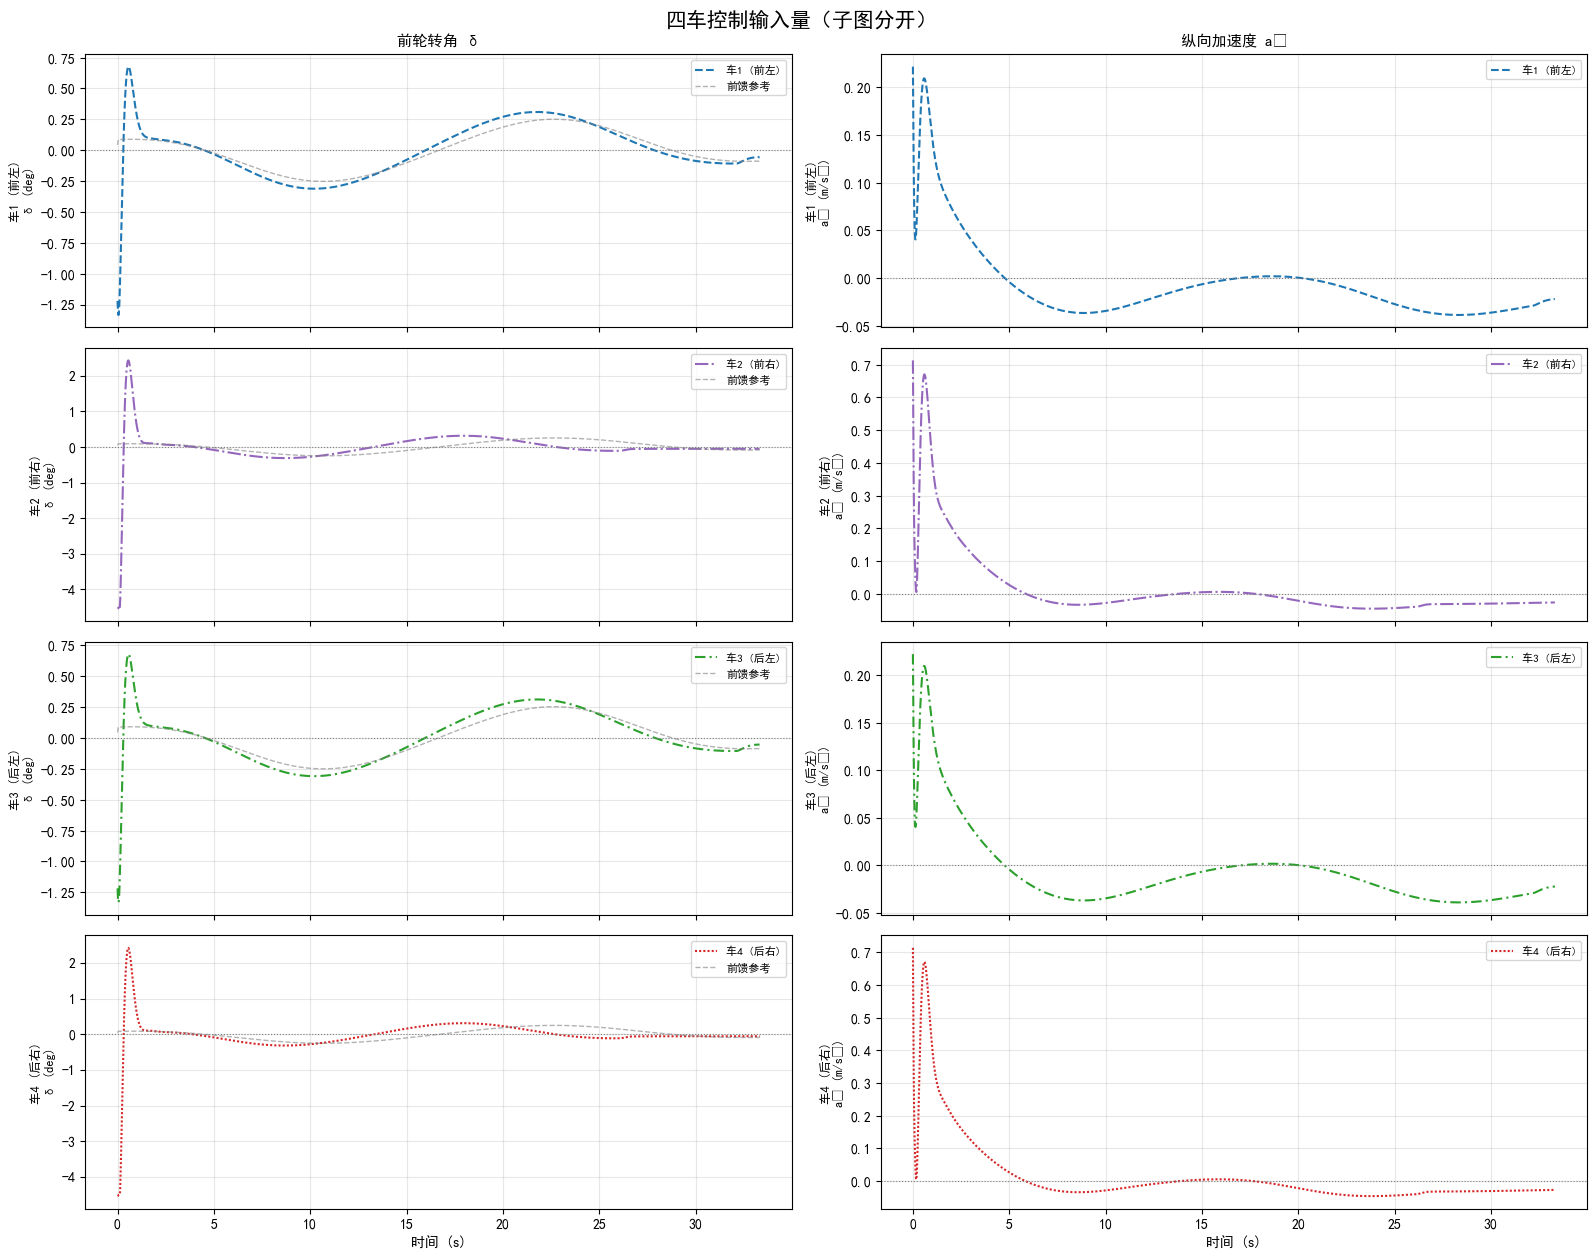

✅ 子图分开版已保存：inputs_separated.png


C:\Users\lj\AppData\Local\Temp\ipykernel_45120\3603268251.py:122: UserWarning: Glyph 8339 (\N{LATIN SUBSCRIPT SMALL LETTER X}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_45120\3603268251.py:122: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_45120\3603268251.py:123: UserWarning: Glyph 8339 (\N{LATIN SUBSCRIPT SMALL LETTER X}) missing from font(s) SimHei.
  plt.savefig('inputs_combined.png', dpi=150, bbox_inches='tight')
C:\Users\lj\AppData\Local\Temp\ipykernel_45120\3603268251.py:123: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig('inputs_combined.png', dpi=150, bbox_inches='tight')


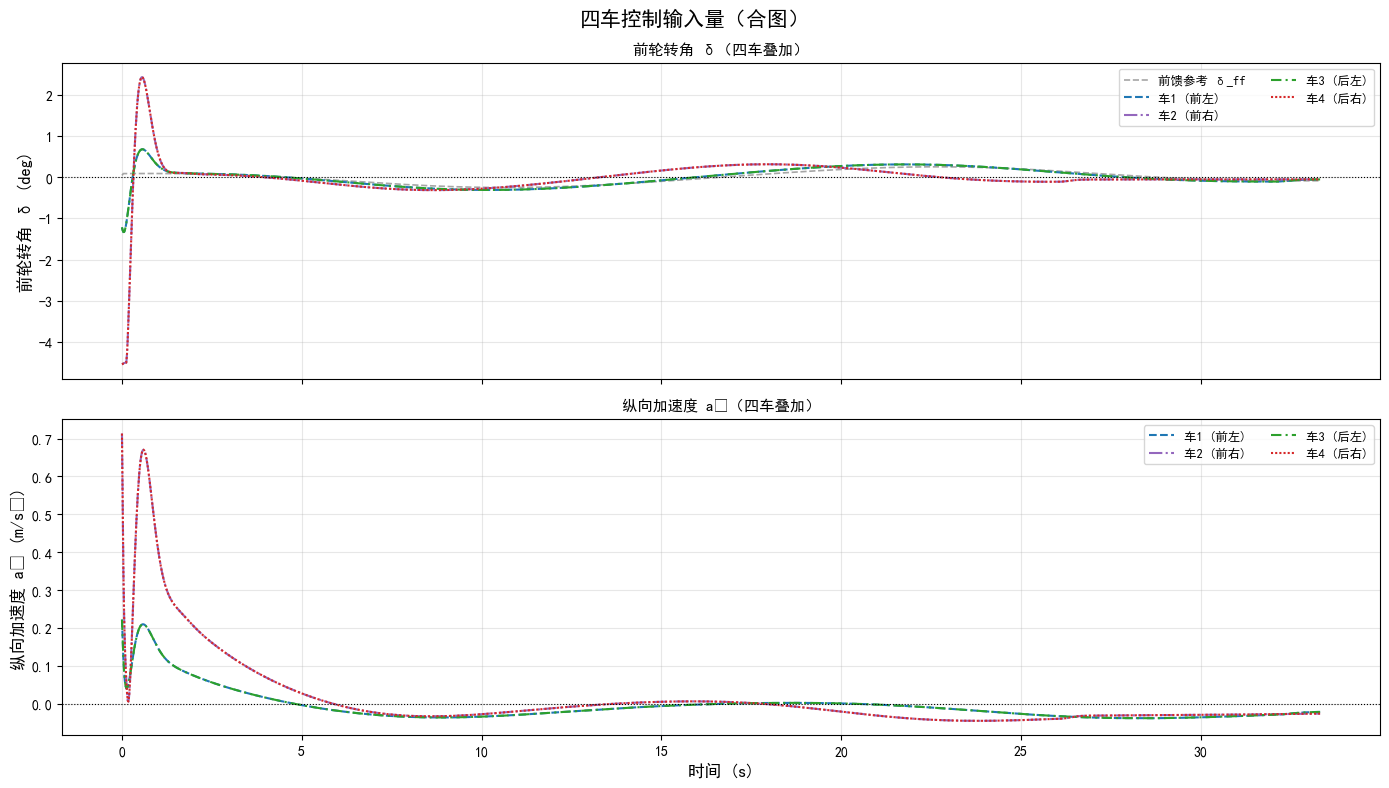

✅ 合图版已保存：inputs_combined.png


C:\Users\lj\AppData\Local\Temp\ipykernel_45120\3603268251.py:171: UserWarning: Glyph 8339 (\N{LATIN SUBSCRIPT SMALL LETTER X}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_45120\3603268251.py:171: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.tight_layout()
C:\Users\lj\AppData\Local\Temp\ipykernel_45120\3603268251.py:172: UserWarning: Glyph 8339 (\N{LATIN SUBSCRIPT SMALL LETTER X}) missing from font(s) SimHei.
  plt.savefig('inputs_dual_axis.png', dpi=150, bbox_inches='tight')
C:\Users\lj\AppData\Local\Temp\ipykernel_45120\3603268251.py:172: UserWarning: Glyph 178 (\N{SUPERSCRIPT TWO}) missing from font(s) SimHei.
  plt.savefig('inputs_dual_axis.png', dpi=150, bbox_inches='tight')


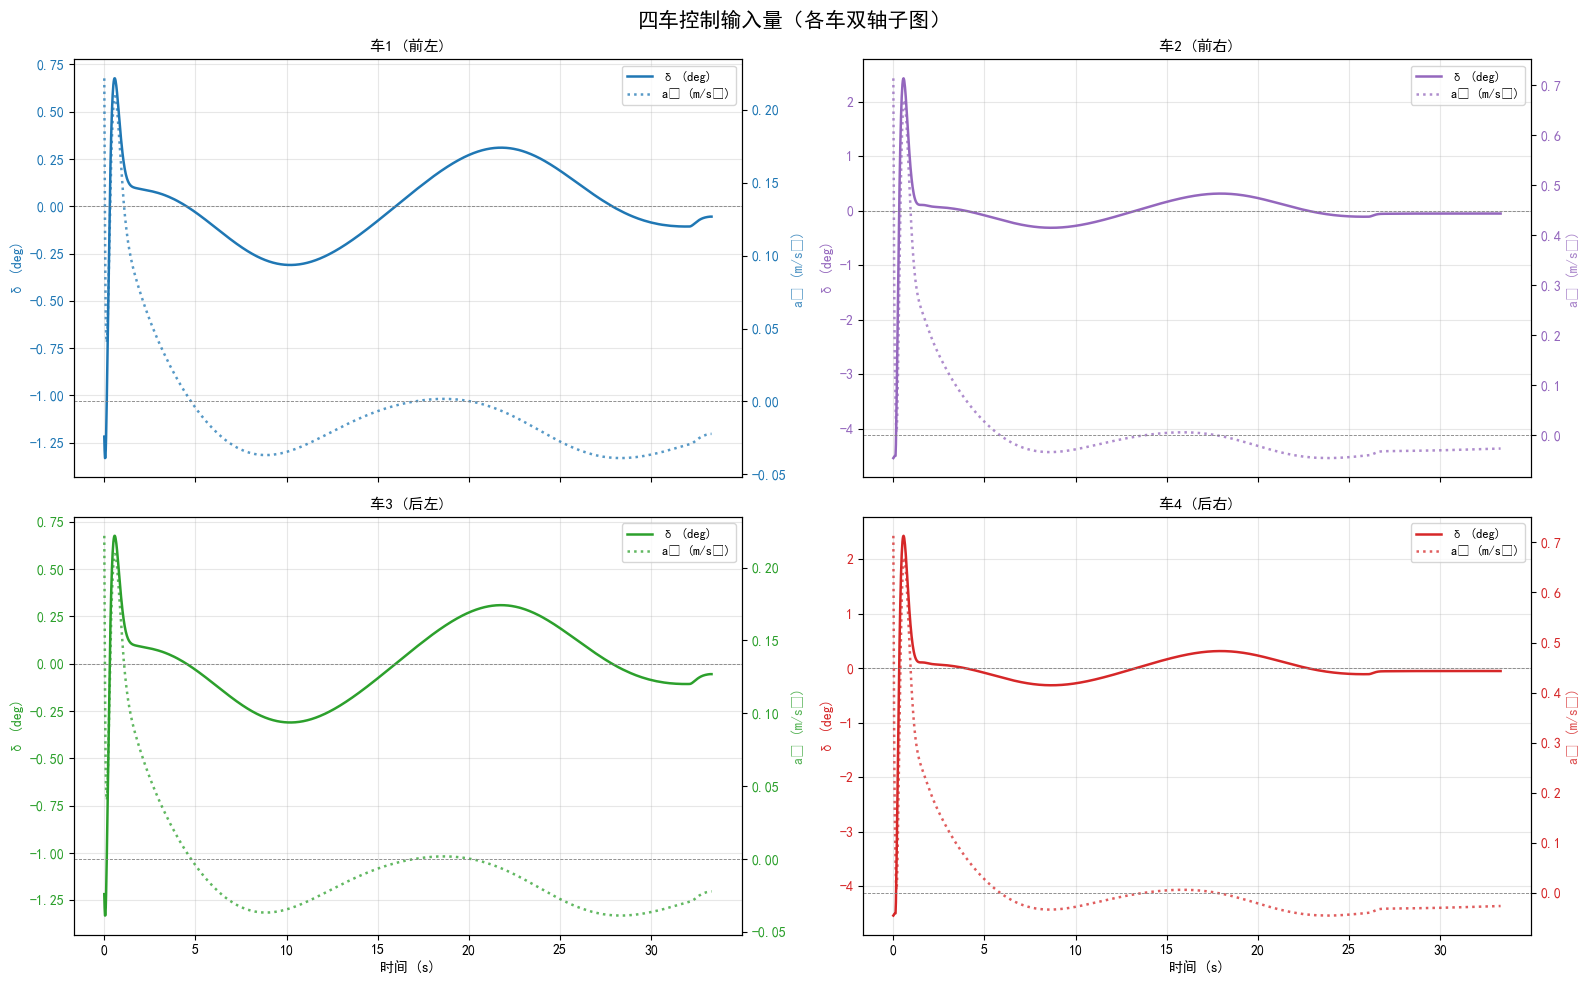

✅ 双轴子图版已保存：inputs_dual_axis.png


In [23]:
# =========================
# 输入量绘图：前轮转角 & 纵向加速度
# =========================
plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# ── 时间轴 ────────────────────────────────────────────────
# u_vehicles[v] shape: (traj_length-1, 2)
N_ctrl = u_vehicles[0].shape[0]  # = traj_length - 1
t_ctrl = np.arange(N_ctrl) * dt  # 单位：秒

# ── 颜色 / 标签 ───────────────────────────────────────────
colors_v = ['tab:blue', 'tab:purple', 'tab:green', 'tab:red']
labels_v = ['车1 (前左)', '车2 (前右)', '车3 (后左)', '车4 (后右)']
ls_v = ['--', '-.', (0, (5, 2, 1, 2)), (0, (1, 1))]

# =========================================================
# 图1：子图分开
#       行 = 4辆车，列 = [前轮转角 | 纵向加速度]
# =========================================================
fig1, axes1 = plt.subplots(
    nrows=num_vehicles, ncols=2,
    figsize=(16, 3.2 * num_vehicles),
    sharex=True
)
fig1.suptitle('四车控制输入量（子图分开）', fontsize=15, fontweight='bold')

for v in range(num_vehicles):
    delta_v = u_vehicles[v][:, 0]  # 前轮转角 (rad)
    ax_v = u_vehicles[v][:, 1]  # 纵向加速度 (m/s²)

    # ── 左列：前轮转角 ─────────────────────────────────
    ax_left = axes1[v, 0]
    ax_left.plot(t_ctrl, np.rad2deg(delta_v),
                 color=colors_v[v], linestyle=ls_v[v], linewidth=1.5,
                 label=labels_v[v])
    ax_left.axhline(0, color='gray', linewidth=0.8, linestyle=':')

    # 画前馈量（纯参考，供对比）
    delta_ff_ref = 0.8 * (sys_pars["lf"] + sys_pars["lr"]) \
                   * curvature_ref_path[:N_ctrl]
    ax_left.plot(t_ctrl, np.rad2deg(delta_ff_ref),
                 color='gray', linewidth=1.0, linestyle='--',
                 alpha=0.6, label='前馈参考')

    ax_left.set_ylabel(f'{labels_v[v]}\nδ (deg)', fontsize=9)
    ax_left.legend(fontsize=8, loc='upper right')
    ax_left.grid(True, alpha=0.3)

    if v == 0:
        ax_left.set_title('前轮转角 δ', fontsize=11)
    if v == num_vehicles - 1:
        ax_left.set_xlabel('时间 (s)', fontsize=10)

    # ── 右列：纵向加速度 ───────────────────────────────
    ax_right = axes1[v, 1]
    ax_right.plot(t_ctrl, ax_v,
                  color=colors_v[v], linestyle=ls_v[v], linewidth=1.5,
                  label=labels_v[v])
    ax_right.axhline(0, color='gray', linewidth=0.8, linestyle=':')

    ax_right.set_ylabel(f'{labels_v[v]}\naₓ (m/s²)', fontsize=9)
    ax_right.legend(fontsize=8, loc='upper right')
    ax_right.grid(True, alpha=0.3)

    if v == 0:
        ax_right.set_title('纵向加速度 aₓ', fontsize=11)
    if v == num_vehicles - 1:
        ax_right.set_xlabel('时间 (s)', fontsize=10)

plt.tight_layout()
plt.savefig('inputs_separated.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 子图分开版已保存：inputs_separated.png")

# =========================================================
# 图2：合图
#       上子图 = 四车前轮转角叠加
#       下子图 = 四车纵向加速度叠加
# =========================================================
fig2, (ax_top, ax_bot) = plt.subplots(
    nrows=2, ncols=1,
    figsize=(14, 8),
    sharex=True
)
fig2.suptitle('四车控制输入量（合图）', fontsize=15, fontweight='bold')

# ── 上图：前轮转角 ─────────────────────────────────────
# 参考前馈线（只画一次）
delta_ff_ref = 0.8 * (sys_pars["lf"] + sys_pars["lr"]) \
               * curvature_ref_path[:N_ctrl]
ax_top.plot(t_ctrl, np.rad2deg(delta_ff_ref),
            color='gray', linewidth=1.2, linestyle='--',
            alpha=0.7, label='前馈参考 δ_ff')

for v in range(num_vehicles):
    delta_v = u_vehicles[v][:, 0]
    ax_top.plot(t_ctrl, np.rad2deg(delta_v),
                color=colors_v[v], linestyle=ls_v[v], linewidth=1.5,
                label=labels_v[v])

ax_top.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax_top.set_ylabel('前轮转角 δ (deg)', fontsize=12)
ax_top.legend(loc='upper right', fontsize=9, ncol=2)
ax_top.grid(True, alpha=0.3)
ax_top.set_title('前轮转角 δ（四车叠加）', fontsize=11)

# ── 下图：纵向加速度 ───────────────────────────────────
for v in range(num_vehicles):
    ax_v = u_vehicles[v][:, 1]
    ax_bot.plot(t_ctrl, ax_v,
                color=colors_v[v], linestyle=ls_v[v], linewidth=1.5,
                label=labels_v[v])

ax_bot.axhline(0, color='black', linewidth=0.8, linestyle=':')
ax_bot.set_ylabel('纵向加速度 aₓ (m/s²)', fontsize=12)
ax_bot.set_xlabel('时间 (s)', fontsize=12)
ax_bot.legend(loc='upper right', fontsize=9, ncol=2)
ax_bot.grid(True, alpha=0.3)
ax_bot.set_title('纵向加速度 aₓ（四车叠加）', fontsize=11)

plt.tight_layout()
plt.savefig('inputs_combined.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 合图版已保存：inputs_combined.png")

# =========================================================
# 图3：四子图版（每辆车一个子图，delta + ax 双轴）
#       左Y轴 = δ (deg)，右Y轴 = aₓ (m/s²)
# =========================================================
fig3, axes3 = plt.subplots(
    nrows=2, ncols=2,
    figsize=(16, 10),
    sharex=True
)
axes3 = axes3.flatten()
fig3.suptitle('四车控制输入量（各车双轴子图）', fontsize=15, fontweight='bold')

for v in range(num_vehicles):
    ax_l = axes3[v]  # 左轴（转角）
    ax_r = ax_l.twinx()  # 右轴（加速度）

    delta_v = np.rad2deg(u_vehicles[v][:, 0])
    accel_v = u_vehicles[v][:, 1]

    l1, = ax_l.plot(t_ctrl, delta_v,
                    color=colors_v[v], linestyle='-', linewidth=1.8,
                    label='δ (deg)')
    l2, = ax_r.plot(t_ctrl, accel_v,
                    color=colors_v[v], linestyle=':', linewidth=1.8,
                    alpha=0.75, label='aₓ (m/s²)')

    ax_l.axhline(0, color='gray', linewidth=0.6, linestyle='--')
    ax_r.axhline(0, color='gray', linewidth=0.6, linestyle='--')

    ax_l.set_ylabel('δ (deg)', fontsize=10, color=colors_v[v])
    ax_r.set_ylabel('aₓ (m/s²)', fontsize=10, color=colors_v[v], alpha=0.8)
    ax_l.tick_params(axis='y', labelcolor=colors_v[v])
    ax_r.tick_params(axis='y', labelcolor=colors_v[v])

    ax_l.set_title(labels_v[v], fontsize=11)
    ax_l.grid(True, alpha=0.3)

    lines = [l1, l2]
    labels_leg = [l.get_label() for l in lines]
    ax_l.legend(lines, labels_leg, loc='upper right', fontsize=9)

    if v >= 2:
        ax_l.set_xlabel('时间 (s)', fontsize=10)

plt.tight_layout()
plt.savefig('inputs_dual_axis.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ 双轴子图版已保存：inputs_dual_axis.png")